# Phase 2: Evolutionary Algorithm Optimization — `EA_Optimization.ipynb`

**Team 1 — NYC Taxi Trip Duration**

## Compliance and Experimental Protocol

This notebook follows the standardized project protocol to ensure fairness, reproducibility, and auditability:

- Only the first **1,000,000 rows** of the dataset are used  
- A **fixed random seed shuffle** is applied before splitting  
- Data is split into **70% train / 15% validation / 15% test**  
- **All tuning and model selection is performed using validation only**  
- The **test set is used exactly once** for final evaluation  
- Final results are executed within the **NRP environment** as required  

These constraints ensure that all models (NN, EA-optimized NN, and FS) are evaluated under identical and fair conditions.


## Split Strategy Clarification (50% vs 70/15/15)

Earlier Phase 1 planning materials referenced a **50% holdout strategy**.  
However, the official **project specification, workflow guide, FAQ, and README** standardize evaluation using a **70/15/15 split**.

For consistency, fairness, and final compliance across all notebooks:
- We adopt **70/15/15** as the authoritative split
- This ensures **comparable evaluation across NN, EA, and FS**
- It also aligns with **validation-based tuning and single-use test evaluation**

This decision removes ambiguity and ensures the evaluation protocol is consistent and defensible during review.


---
## Words We Use in This Notebook (Glossary)

Before reading the code, here is a more visual version of the main terms. The goal is to make the notebook easier to follow even if you are new to machine learning.



<div style="display:flex; flex-wrap:wrap; gap:14px; margin:12px 0 4px 0;">

<div style="flex:1 1 360px; min-width:320px; border:1px solid #BFD7F4; border-radius:14px; padding:14px 16px; background:#F8FBFF;">
  <div style="font-size:18px; font-weight:700; margin-bottom:10px;">Models and settings</div>
  <ul style="margin:0 0 0 18px; padding:0; line-height:1.45;">
    <li style="margin:0 0 8px 0;"><b>Model:</b> A program that learns from data to make predictions.</li><li style="margin:0 0 8px 0;"><b>Baseline model:</b> A simpler reference model we compare against.</li><li style="margin:0 0 8px 0;"><b>Neural network:</b> A model that learns patterns by adjusting many small weights.</li><li style="margin:0 0 8px 0;"><b>Hyperparameter:</b> A setting chosen before training, like learning rate or number of layers.</li><li style="margin:0 0 8px 0;"><b>Log-transform:</b> Using log(x+1) so very long trips do not dominate the learning process.</li><li style="margin:0 0 8px 0;"><b>Z-score scaling:</b> Putting features on a similar scale so the model trains more smoothly.</li>
  </ul>
</div>
<div style="flex:1 1 360px; min-width:320px; border:1px solid #F5C978; border-radius:14px; padding:14px 16px; background:#FFF9EF;">
  <div style="font-size:18px; font-weight:700; margin-bottom:10px;">EA search words</div>
  <ul style="margin:0 0 0 18px; padding:0; line-height:1.45;">
    <li style="margin:0 0 8px 0;"><b>Evolutionary Algorithm (EA):</b> A search method that improves solutions over time.</li><li style="margin:0 0 8px 0;"><b>Genetic Algorithm (GA):</b> A type of EA that uses selection, crossover, and mutation.</li><li style="margin:0 0 8px 0;"><b>Individual / candidate:</b> One specific hyperparameter choice being tested.</li><li style="margin:0 0 8px 0;"><b>Population:</b> A group of candidates in one round.</li><li style="margin:0 0 8px 0;"><b>Generation:</b> One round of the search.</li><li style="margin:0 0 8px 0;"><b>Fitness:</b> The score used to judge a candidate. Here, fitness = validation R².</li>
  </ul>
</div>
<div style="flex:1 1 360px; min-width:320px; border:1px solid #9DD5A5; border-radius:14px; padding:14px 16px; background:#EEF8F1;">
  <div style="font-size:18px; font-weight:700; margin-bottom:10px;">How candidates change</div>
  <ul style="margin:0 0 0 18px; padding:0; line-height:1.45;">
    <li style="margin:0 0 8px 0;"><b>Selection:</b> Keeping the better candidates as parents.</li><li style="margin:0 0 8px 0;"><b>Crossover:</b> Mixing two parents to create a child candidate.</li><li style="margin:0 0 8px 0;"><b>Mutation:</b> Making a small random change to explore new options.</li><li style="margin:0 0 8px 0;"><b>Elitism:</b> Keeping the best candidate unchanged so a good solution is not lost.</li>
  </ul>
</div>
<div style="flex:1 1 360px; min-width:320px; border:1px solid #D4B9E8; border-radius:14px; padding:14px 16px; background:#FBF7FF;">
  <div style="font-size:18px; font-weight:700; margin-bottom:10px;">Evaluation words</div>
  <ul style="margin:0 0 0 18px; padding:0; line-height:1.45;">
    <li style="margin:0 0 8px 0;"><b>Training set:</b> The 70% used to teach the model.</li><li style="margin:0 0 8px 0;"><b>Validation set:</b> The 15% used during tuning and EA search.</li><li style="margin:0 0 8px 0;"><b>Test set:</b> The 15% saved for the final honest score.</li><li style="margin:0 0 8px 0;"><b>R²:</b> How much variation the model explains. Higher is better.</li><li style="margin:0 0 8px 0;"><b>MAPE:</b> Average percent error. Lower is better.</li><li style="margin:0 0 8px 0;"><b>RMSE:</b> Error in seconds that punishes big mistakes more.</li><li style="margin:0 0 8px 0;"><b>MAE:</b> Average absolute error in seconds.</li><li style="margin:0 0 8px 0;"><b>Bootstrap confidence interval:</b> A resampling method that checks whether a difference is likely real.</li>
  </ul>
</div>
</div>

<div style="margin-top:10px; font-size:15px; color:#374151;">
<b>Reading tip:</b> if you forget a term later, come back to this section first. Most of the notebook is built from these same ideas.
</div>


---
### What this notebook does

In this notebook, we use an **Evolutionary Algorithm (EA)** to optimize the hyperparameters of the **Phase 1 neural network** for NYC taxi trip duration prediction.

The goal is intentionally narrow and defensible:

- keep the **same feature pipeline and split protocol**
- stay within the **same general MLP family used in Phase 1**
- use a **fixed, auditable search budget**
- test whether automated search can beat the Phase 1 NN on the held-out test set

This means Phase 2 is **not** a model-redesign exercise. It is a controlled hyperparameter-optimization experiment.

---

### How the idea works

Instead of hand-picking one configuration, we let the EA search over many candidate settings:

- start with many different candidates
- train each candidate on the **training set only**
- score each candidate on the **validation set only**
- keep and recombine stronger candidates
- repeat across generations under a fixed budget

Over time, the search should move toward regions of the hyperparameter space that give better validation performance.

---

### Why we do this

Neural networks are highly sensitive to training settings such as:

- learning rate
- dropout
- layer sizes
- weight decay
- batch size

A manual search can find a strong baseline, but an EA gives us a systematic way to ask whether **extra optimization effort** produces a better final model.

---

### What we compare at the end

At the end of the notebook, we compare:

- the **Phase 1 NN reference model** selected with validation-only tuning
- the **EA-optimized NN** selected with the fixed Phase 2 search budget

We evaluate both on the **same held-out test set** using:

- **R²** (higher is better)
- **MAPE** (lower is better)

The main Phase 2 question is therefore:

👉 *Under this fixed compute budget, did the EA produce a better neural network than the Phase 1 reference, and was that extra compute worth it?*


---
## How to Run This Notebook

Follow these steps to run the notebook from start to finish:

1. **Open the notebook in NRP JupyterHub (required for final results).**  
   You may test locally, but all final experiments must be run on NRP to ensure fairness and reproducibility.

2. **Check your compute device.**  
   The first code cell will show whether you are using a GPU or CPU.  
   - GPU: faster (recommended)  
   - CPU: works correctly but may take longer  

3. **Run every cell in order, from top to bottom.**  
   In Jupyter, click `Kernel → Restart & Run All`.

4. **Do not skip cells or run them out of order.**  
   Each step depends on previous outputs.

5. **Output files** (plots, logs, and saved models) will be created automatically in the `../artifacts/phase2/` folder.

6. **Expected runtime:**  
   The full Evolutionary Algorithm run may take **15–60 minutes** depending on hardware.

---

### ⚠️ Quick Test Mode (Optional)

If you only want to check that the notebook runs correctly:

- You may temporarily reduce:
  - `GENERATIONS` (e.g., 2)
  - `POPULATION_SIZE` (e.g., 5)

👉 **Important:** These reduced settings are only for testing.  
You must restore the original values before generating final results, since the project requires a fixed compute budget for fair comparison.


---
## Fair Evaluation Rules

To make sure our results are honest and trustworthy, we follow strict rules about how data is used.

We use a **70% / 15% / 15% split** (train / validation / test).



<div style="display:flex; flex-wrap:wrap; gap:14px; margin:12px 0;">

<div style="flex:1 1 250px; min-width:250px; border:1px solid #BFD7F4; border-radius:14px; padding:14px 16px; background:#F8FBFF;">
  <div style="font-size:18px; font-weight:700; margin-bottom:8px;">Training set (70%)</div>
  <div style="line-height:1.5;">Used to teach the neural network. Every candidate trains on this part.</div>
</div>
<div style="flex:1 1 250px; min-width:250px; border:1px solid #F5C978; border-radius:14px; padding:14px 16px; background:#FFF9EF;">
  <div style="font-size:18px; font-weight:700; margin-bottom:8px;">Validation set (15%)</div>
  <div style="line-height:1.5;">Used during the EA search to score fitness and compare candidates.</div>
</div>
<div style="flex:1 1 250px; min-width:250px; border:1px solid #9DD5A5; border-radius:14px; padding:14px 16px; background:#EEF8F1;">
  <div style="font-size:18px; font-weight:700; margin-bottom:8px;">Test set (15%)</div>
  <div style="line-height:1.5;">Saved for one final honest check after tuning is completely finished.</div>
</div>
</div>

### Why this matters

- The **training set** is where the model learns.  
- The **validation set** helps the EA choose better hyperparameters.  
- The **test set** stays untouched until the end, so the final score is fair.  

<div style="margin-top:8px; padding:12px 14px; border-left:4px solid #DC2626; background:#FEF2F2;">
<b>Important:</b> if the test set is used too early, the model can accidentally "learn" the answers and the final result will look better than it really is. That is called <b>data leakage</b>.
</div>


---
## GPU Preflight Check

> **What this does:** Checks whether a GPU (graphics processing unit) is available. A GPU can speed up model training significantly.  
> **Why it matters:** If no GPU is found, the notebook will still run correctly, but training may be slower. On NRP, make sure you are using the correct environment if faster execution is needed.


In [1]:
# --- Cell explanation: this cell performs part of the pipeline ---
# 🔍 GPU Preflight Check (Run this BEFORE the EA cell)
# Import os so this cell can use that library.
import os
# Import tensorflow as tf so this cell can use that library.
import tensorflow as tf

# Print a message or result so the notebook shows useful runtime feedback.
print("=== GPU PRECHECK ===")
# Compute or store a value in `gpus` for use later in the notebook.
gpus = tf.config.list_physical_devices("GPU")
# Print a message or result so the notebook shows useful runtime feedback.
print("TensorFlow version:", tf.__version__)
# Print a message or result so the notebook shows useful runtime feedback.
print("GPU count:", len(gpus))

# Conditional check: run this block only when gpus is true.
if gpus:
    # Loop over i, gpu in enumerate(gpus) so the same operations are applied repeatedly.
    for i, gpu in enumerate(gpus):
        # Print a message or result so the notebook shows useful runtime feedback.
        print(f"GPU {i}:", gpu)
    # Print a message or result so the notebook shows useful runtime feedback.
    print("Running on GPU")
# Else branch: handle the alternate or cleanup path.
else:
    # Print a message or result so the notebook shows useful runtime feedback.
    print("Running on CPU — STOP if you expected GPU")

# Print a message or result so the notebook shows useful runtime feedback.
print(
    # Execute this line as part of the current analysis step.
    "NRP image hint:",
    # Execute this line as part of the current analysis step.
    os.environ.get("JUPYTER_IMAGE_SPEC")
    # Execute this line as part of the current analysis step.
    or os.environ.get("CONTAINER_IMAGE")
    # Execute this line as part of the current analysis step.
    or os.environ.get("JUPYTERHUB_IMAGE")
    # Execute this line as part of the current analysis step.
    or os.environ.get("IMAGE_NAME")
    # Execute this line as part of the current analysis step.
    or "UNKNOWN",
# Execute this line as part of the current analysis step.
)
# Print a message or result so the notebook shows useful runtime feedback.
print("=== END PRECHECK ===")

2026-05-02 02:17:23.647242: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-02 02:17:24.228359: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/nvidia/lib:/usr/local/nvidia/lib64
2026-05-02 02:17:24.228461: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer_plugin.so.7'; dlerror: libnvinfer_plugin.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/nvidia/lib:/usr/local/nvidia/lib64
2026-05-02 02:17:24.228474: W tensorfl

=== GPU PRECHECK ===
TensorFlow version: 2.11.0
GPU count: 1
GPU 0: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
Running on GPU
NRP image hint: gitlab-registry.nrp-nautilus.io/prp/jupyter-stack/prp-pytorch2:v1.0
=== END PRECHECK ===


2026-05-02 02:17:24.947848: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-05-02 02:17:24.975754: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-05-02 02:17:24.978084: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero


## Cell 1 — Imports, Constants & TensorFlow/Keras Device

> **What this does:** Loads all required Python libraries and defines key constants that control the entire notebook.  
> **Why it matters:** All later steps depend on these settings. Keeping them fixed ensures the experiment is consistent and reproducible.

---

### EA Data & Evaluation Protocol

#### Data Splits
- **Train set:** Used ONLY for neural network training.  
- **Validation set:** Used ONLY for EA fitness evaluation (selecting the best candidate).  
- **Test set:** Never used during EA evolution. Used exactly once at the very end for final evaluation.  

---

#### Split Policy
- The same **70/15/15 split from Phase 1 is reused**.  
- The same random seed (`SEED = 42`) is used to keep results consistent across runs.  
- No reshuffling or resplitting occurs inside this notebook.  

---

#### Evaluation Discipline
- EA fitness is computed using **validation R² on the original scale (seconds)** so results are directly comparable to the baseline model.  
- Validation **MAPE** is tracked as a secondary metric.  
- **Test metrics are computed exactly once after EA completes**, ensuring no data leakage.


In [2]:
# --- Cell explanation: this cell performs part of the pipeline ---
# Import specific tools from pathlib for use below.
from pathlib import Path
# Import os so this cell can use that library.
import os

# Compute or store a value in `os.environ["TF_CPP_MIN_LOG_LEVEL"]` for use later in the notebook.
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "1"

# Import numpy as np so this cell can use that library.
import numpy as np
# Import pandas as pd so this cell can use that library.
import pandas as pd
# Import tensorflow as tf so this cell can use that library.
import tensorflow as tf
# Import specific tools from tensorflow.keras for use below.
from tensorflow.keras import Sequential
# Import specific tools from tensorflow.keras.layers for use below.
from tensorflow.keras.layers import Dense, Dropout, Input
# Import specific tools from tensorflow.keras for use below.
from tensorflow.keras import regularizers

# Splitting dataset into train/test to evaluate generalization
# Import specific tools from sklearn.model_selection for use below.
from sklearn.model_selection import train_test_split
# Import specific tools from sklearn.linear_model for use below.
from sklearn.linear_model import Ridge
# Import specific tools from sklearn.metrics for use below.
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ── Constants (identical to Phase 1) ──
# Compute or store a value in `SEED` for use later in the notebook.
SEED = 42
# Compute or store a value in `NROWS` for use later in the notebook.
NROWS = 1_000_000
# Compute or store a value in `TARGET` for use later in the notebook.
TARGET = "trip_duration"
# Compute or store a value in `CLIP_MIN` for use later in the notebook.
CLIP_MIN = -2.0
# Compute or store a value in `CLIP_MAX` for use later in the notebook.
CLIP_MAX = 13.0

# Compute or store a value in `DATA_PATH` for use later in the notebook.
DATA_PATH = Path("../data/train.csv")
# Compute or store a value in `DATA_URL` for use later in the notebook.
DATA_URL = "https://github.com/DrAlzahraniProjects/csusb_spring26_cse5140_team1/releases/download/v1.0/train.csv"

# Compute or store a value in `ARTIFACTS_DIR` for use later in the notebook.
ARTIFACTS_DIR = Path("../artifacts/phase2")
# Create the directory if needed so later files can be written safely.
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

# Compute or store a value in `gpus` for use later in the notebook.
gpus = tf.config.list_physical_devices("GPU")
# Loop over gpu in gpus so the same operations are applied repeatedly.
for gpu in gpus:
    # Try branch: handle the alternate or cleanup path.
    try:
        # Execute this line as part of the current analysis step.
        tf.config.experimental.set_memory_growth(gpu, True)
    # Execute this line as part of the current analysis step.
    except Exception:
        # Explicitly do nothing here because no action is required in this branch.
        pass

# Compute or store a value in `device` for use later in the notebook.
device = "GPU" if gpus else "CPU"

# Print a message or result so the notebook shows useful runtime feedback.
print("=" * 60)
# Print a message or result so the notebook shows useful runtime feedback.
print("EA_Optimization.ipynb — Phase 2")
# Print a message or result so the notebook shows useful runtime feedback.
print("=" * 60)
# Print a message or result so the notebook shows useful runtime feedback.
print(f"  SEED:      {SEED}")
# Print a message or result so the notebook shows useful runtime feedback.
print(f"  NROWS:     {NROWS:,}")
# Print a message or result so the notebook shows useful runtime feedback.
print(f"  TARGET:    {TARGET}")
# Print a message or result so the notebook shows useful runtime feedback.
print(f"  DATA_PATH: {DATA_PATH}")
# Print a message or result so the notebook shows useful runtime feedback.
print(f"  Device:    {device}")
# Print a message or result so the notebook shows useful runtime feedback.
print(f"  Visible GPUs: {len(gpus)}")
# Print a message or result so the notebook shows useful runtime feedback.
print("=" * 60)

EA_Optimization.ipynb — Phase 2
  SEED:      42
  NROWS:     1,000,000
  TARGET:    trip_duration
  DATA_PATH: ../data/train.csv
  Device:    GPU
  Visible GPUs: 1


## Cell 2 — Deterministic Seeding

> **What this does:** Sets Python, NumPy, and TensorFlow/Keras random number generators to the same starting point.  
> **Why it matters:** This makes results as consistent as possible across runs. Random steps like data shuffling and weight initialization will behave the same way each time, which helps us fairly compare models.

`SEED = 42` → This is an arbitrary but fixed number. Any number would work; 42 is a common convention. The important thing is that it stays the same for reproducibility.


In [3]:
# --- Cell explanation: this cell performs part of the pipeline ---
# Import os so this cell can use that library.
import os
# Import random so this cell can use that library.
import random

# Function definition: encapsulates reusable logic
# Seeding random generators for reproducibility
# Define the function `seed_everything` so this logic can be reused later.
def seed_everything(seed=SEED):
    # Compute or store a value in `os.environ["PYTHONHASHSEED"]` for use later in the notebook.
    os.environ["PYTHONHASHSEED"] = str(seed)
    # Execute this line as part of the current analysis step.
    random.seed(seed)
    # Execute this line as part of the current analysis step.
    np.random.seed(seed)
    # Execute this line as part of the current analysis step.
    tf.keras.utils.set_random_seed(seed)

# Execute this line as part of the current analysis step.
seed_everything(SEED)
# Print a message or result so the notebook shows useful runtime feedback.
print(f"All RNGs seeded with {SEED}")

All RNGs seeded with 42


---
# Step 1.1 — Data Verification

Verify that Phase 2 uses the exact same dataset, shuffle, and splits as Phase 1.

> **What this does:** Loads the NYC taxi trip dataset (first 1 million rows) using the same procedure as Phase 1, including the same shuffle and random seed.  
> **Why it matters:** Using identical data ensures that any performance differences between models are due to the method (EA optimization), not changes in the data.

---

## Cell 3 — Load Dataset

- Load the first **1,000,000 rows** (project requirement).
- Shuffle using the same seed (`SEED = 42`) to ensure the same row order as Phase 1.
- No changes to the dataset, preprocessing, or splitting are made in this step.


In [4]:
# --- Cell explanation: this cell performs part of the pipeline ---
# Conditional check: run this block only when not DATA_PATH.exists() is true.
if not DATA_PATH.exists():
    # Import urllib.request so this cell can use that library.
    import urllib.request
    # Create the directory if needed so later files can be written safely.
    DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
    # Print a message or result so the notebook shows useful runtime feedback.
    print("Downloading dataset...")
    # Execute this line as part of the current analysis step.
    urllib.request.urlretrieve(DATA_URL, DATA_PATH)
    # Print a message or result so the notebook shows useful runtime feedback.
    print("Download complete.")
# Else branch: handle the alternate or cleanup path.
else:
    # Print a message or result so the notebook shows useful runtime feedback.
    print("Dataset already exists at", DATA_PATH)

# Compute or store a value in `df` for use later in the notebook.
df = pd.read_csv(DATA_PATH, nrows=NROWS)
# Print a message or result so the notebook shows useful runtime feedback.
print(f"Loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")

# Seeding random generators for reproducibility
# Compute or store a value in `df` for use later in the notebook.
df = df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
# Seeding random generators for reproducibility
# Print a message or result so the notebook shows useful runtime feedback.
print(f"Shuffled with seed={SEED}")
# Print a message or result so the notebook shows useful runtime feedback.
print(f"First 3 IDs after shuffle: {df['id'].head(3).tolist()}")

Dataset already exists at ../data/train.csv
Loaded: 1,000,000 rows, 11 columns
Shuffled with seed=42
First 3 IDs after shuffle: ['id3435429', 'id2267606', 'id3771460']


## Cell 4 — Train / Validation / Test Splits

> **What this does:** Splits the 1 million rows into three groups (train, validation, and test).  
> **Why it matters:** Keeping these groups separate prevents **data leakage**, which happens when information from evaluation data influences training. This ensures our final results are honest and reliable.

Phase 2 reuses the exact same split from Phase 1:

- **70% Train (~700,000 rows)** — the model learns from these  
- **15% Validation (~150,000 rows)** — the EA uses these to score candidates (fitness)  
- **15% Test (~150,000 rows)** — saved for the final evaluation and used **exactly once**

- The same split is reused with no reshuffling or resplitting.  
- `random_state=SEED` ensures the split is consistent and reproducible across runs.


In [5]:
# --- Cell explanation: this cell performs part of the pipeline ---
# ── Official 70/15/15 split (reuse Phase 1 policy) ──
# Splitting dataset into train/test to evaluate generalization
# Seeding random generators for reproducibility
# Compute or store a value in `dev_df, test_df` for use later in the notebook.
dev_df, test_df = train_test_split(df, test_size=0.15, random_state=SEED)
# Splitting dataset into train/test to evaluate generalization
# Seeding random generators for reproducibility
# Compute or store a value in `train_df, val_df` for use later in the notebook.
train_df, val_df = train_test_split(dev_df, test_size=(0.15/0.85), random_state=SEED)

# Print a message or result so the notebook shows useful runtime feedback.
print("Split sizes:")
# Print a message or result so the notebook shows useful runtime feedback.
print(f"  train_df: {len(train_df):>8,} rows  (70%)")
# Print a message or result so the notebook shows useful runtime feedback.
print(f"  val_df:   {len(val_df):>8,} rows  (15%)")
# Print a message or result so the notebook shows useful runtime feedback.
print(f"  test_df:  {len(test_df):>8,} rows  (15%)")
# Print a message or result so the notebook shows useful runtime feedback.
print(f"  total:    {len(train_df) + len(val_df) + len(test_df):>8,} rows")

# ── Assertions ──
# Assert that this condition holds to catch a problem early if it fails.
assert len(train_df) + len(val_df) + len(test_df) == NROWS, "Row count mismatch!"
# Assert that this condition holds to catch a problem early if it fails.
assert abs(len(train_df) - 700_000) < 1000, f"Train expected ~700k, got {len(train_df)}"
# Assert that this condition holds to catch a problem early if it fails.
assert abs(len(val_df) - 150_000) < 1000,   f"Val expected ~150k, got {len(val_df)}"
# Assert that this condition holds to catch a problem early if it fails.
assert abs(len(test_df) - 150_000) < 1000,  f"Test expected ~150k, got {len(test_df)}"

# Print a message or result so the notebook shows useful runtime feedback.
print("\n✅ All split assertions passed — 70/15/15 verified")

Split sizes:
  train_df:  700,000 rows  (70%)
  val_df:    150,000 rows  (15%)
  test_df:   150,000 rows  (15%)
  total:    1,000,000 rows

✅ All split assertions passed — 70/15/15 verified


## Cell 6 — Step 1.1 Summary

> **What this does:** Prints a verification table to confirm the dataset, row counts, and split sizes match Phase 1.  
> **Why it matters:** This ensures the experiment is consistent and reproducible. If anything is incorrect (such as wrong row count or seed), it will be detected before training begins.

In [6]:
# --- Cell explanation: this cell performs part of the pipeline ---
# Compute or store a value in `verification_summary` for use later in the notebook.
verification_summary = pd.DataFrame([
    # Execute this line as part of the current analysis step.
    {"Check": "Dataset rows loaded", "Expected": "1,000,000", "Actual": f"{len(df):,}", "Status": "✅"},
# Seeding random generators for reproducibility
    # Execute this line as part of the current analysis step.
    {"Check": "Random seed", "Expected": "42", "Actual": str(SEED), "Status": "✅"},

    # Execute this line as part of the current analysis step.
    {"Check": "Train rows", "Expected": "~700,000", "Actual": f"{len(train_df):,}", "Status": "✅"},
    # Execute this line as part of the current analysis step.
    {"Check": "Validation rows", "Expected": "~150,000", "Actual": f"{len(val_df):,}", "Status": "✅"},
    # Execute this line as part of the current analysis step.
    {"Check": "Test rows", "Expected": "~150,000", "Actual": f"{len(test_df):,}", "Status": "✅"},

    # Execute this line as part of the current analysis step.
    {"Check": "Total rows", "Expected": "1,000,000",
     # Execute this line as part of the current analysis step.
     "Actual": f"{len(train_df)+len(val_df)+len(test_df):,}", "Status": "✅"},

    # Execute this line as part of the current analysis step.
    {"Check": "No re-splitting", "Expected": "Single split only",
# Seeding random generators for reproducibility
     # Compute or store a value in `"Actual": f"random_state` for use later in the notebook.
     "Actual": f"random_state={SEED}", "Status": "✅"},
# Execute this line as part of the current analysis step.
])

# Print a message or result so the notebook shows useful runtime feedback.
print("=" * 60)
# Print a message or result so the notebook shows useful runtime feedback.
print("STEP 1.1 — DATA VERIFICATION RESULTS (70/15/15)")
# Print a message or result so the notebook shows useful runtime feedback.
print("=" * 60)
# Print a message or result so the notebook shows useful runtime feedback.
print(verification_summary.to_string(index=False))
# Print a message or result so the notebook shows useful runtime feedback.
print("\n✅ Step 1.1 complete — dataset and 70/15/15 splits verified")

STEP 1.1 — DATA VERIFICATION RESULTS (70/15/15)
              Check          Expected          Actual Status
Dataset rows loaded         1,000,000       1,000,000      ✅
        Random seed                42              42      ✅
         Train rows          ~700,000         700,000      ✅
    Validation rows          ~150,000         150,000      ✅
          Test rows          ~150,000         150,000      ✅
         Total rows         1,000,000       1,000,000      ✅
    No re-splitting Single split only random_state=42      ✅

✅ Step 1.1 complete — dataset and 70/15/15 splits verified


### Visual guide — What the Step 1.1 table is confirming



In plain language, this means Phase 2 is using the **same starting point** as Phase 1. That matters because we want any difference in performance to come from the **optimization method**, not from a different dataset or a different split.


---
# Step 1.2 — Feature & Preprocessing Consistency

Verify that the same feature engineering pipeline and scaling procedure from Phase 1 are applied exactly the same way.

---

## Cell 7 — Feature Engineering Functions

> **What this does:** Defines functions that convert raw taxi data (such as pickup time and GPS coordinates) into numerical features that a neural network can use.  
> **Why it matters:** The model cannot directly understand dates or locations, so we transform them into meaningful numbers. Using the exact same features as Phase 1 ensures a fair and consistent comparison.

---

### Feature families

- **Temporal:** pickup hour, day of week, month, plus cyclical (sin/cos) versions so the model understands that hour 23 and hour 0 are close together  
- **Spatial:** differences in latitude/longitude and straight-line distance (haversine distance)  
- **Context (proxies):** passenger count, store-and-forward flag, and vendor ID (simple indicators that may affect trip duration)

---

### Consistency rules

- The exact same feature set from Phase 1 is used (no new or modified features).  
- The same preprocessing steps are applied in the same order.  
- Any scaling or normalization uses **training data only**, preventing data leakage.  
- This ensures results are reproducible and differences come only from the EA optimization.


In [7]:
# --- Cell explanation: this cell performs part of the pipeline ---
# Function definition: encapsulates reusable logic
# Define the function `haversine_km` so this logic can be reused later.
def haversine_km(lat1, lon1, lat2, lon2):
    # Start a documentation string that explains the block below.
    """Vectorized Haversine distance in km."""
    # Compute or store a value in `R` for use later in the notebook.
    R = 6371.0
    # Compute or store a value in `lat1` for use later in the notebook.
    lat1 = np.radians(lat1); lon1 = np.radians(lon1)
    # Compute or store a value in `lat2` for use later in the notebook.
    lat2 = np.radians(lat2); lon2 = np.radians(lon2)
    # Compute or store a value in `dlat` for use later in the notebook.
    dlat = lat2 - lat1
    # Compute or store a value in `dlon` for use later in the notebook.
    dlon = lon2 - lon1
    # Compute or store a value in `a` for use later in the notebook.
    a = np.sin(dlat/2.0)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2.0)**2
    # Return the computed value so the caller can use it.
    return 2 * R * np.arcsin(np.sqrt(a))

# Function definition: encapsulates reusable logic
# Define the function `build_features` so this logic can be reused later.
def build_features(dfin: pd.DataFrame) -> pd.DataFrame:
    # Compute or store a value in `X` for use later in the notebook.
    X = pd.DataFrame(index=dfin.index)

    # Temporal
    # Compute or store a value in `dt` for use later in the notebook.
    dt = pd.to_datetime(dfin["pickup_datetime"], errors="coerce")
    # Compute or store a value in `X["pickup_hour"]` for use later in the notebook.
    X["pickup_hour"]  = dt.dt.hour.fillna(0).astype(int)
    # Compute or store a value in `X["pickup_dow"]` for use later in the notebook.
    X["pickup_dow"]   = dt.dt.dayofweek.fillna(0).astype(int)
    # Compute or store a value in `X["pickup_month"]` for use later in the notebook.
    X["pickup_month"] = dt.dt.month.fillna(0).astype(int)

    # Compute or store a value in `X["hour_sin"]` for use later in the notebook.
    X["hour_sin"] = np.sin(2*np.pi*X["pickup_hour"]/24)
    # Compute or store a value in `X["hour_cos"]` for use later in the notebook.
    X["hour_cos"] = np.cos(2*np.pi*X["pickup_hour"]/24)
    # Compute or store a value in `X["dow_sin"]` for use later in the notebook.
    X["dow_sin"]  = np.sin(2*np.pi*X["pickup_dow"]/7)
    # Compute or store a value in `X["dow_cos"]` for use later in the notebook.
    X["dow_cos"]  = np.cos(2*np.pi*X["pickup_dow"]/7)

    # Spatial
    # Compute or store a value in `X["delta_lat"]` for use later in the notebook.
    X["delta_lat"] = (dfin["dropoff_latitude"] - dfin["pickup_latitude"]).astype(float)
    # Compute or store a value in `X["delta_lon"]` for use later in the notebook.
    X["delta_lon"] = (dfin["dropoff_longitude"] - dfin["pickup_longitude"]).astype(float)
    # Compute or store a value in `X["haversine_km"]` for use later in the notebook.
    X["haversine_km"] = haversine_km(
        # Execute this line as part of the current analysis step.
        dfin["pickup_latitude"].astype(float),
        # Execute this line as part of the current analysis step.
        dfin["pickup_longitude"].astype(float),
        # Execute this line as part of the current analysis step.
        dfin["dropoff_latitude"].astype(float),
        # Execute this line as part of the current analysis step.
        dfin["dropoff_longitude"].astype(float),
    # Execute this line as part of the current analysis step.
    )

    # Proxies
    # Compute or store a value in `X["passenger_count"]` for use later in the notebook.
    X["passenger_count"] = pd.to_numeric(dfin["passenger_count"], errors="coerce").fillna(0.0)
    # Execute this line as part of the current analysis step.
    X["store_and_fwd_Y"] = (dfin["store_and_fwd_flag"].astype(str).str.upper() == "Y").astype(int)

    # Compute or store a value in `vendor_oh` for use later in the notebook.
    vendor_oh = pd.get_dummies(dfin["vendor_id"].astype(str), prefix="vendor", drop_first=False)
    # Compute or store a value in `X` for use later in the notebook.
    X = pd.concat([X, vendor_oh], axis=1)

    # Compute or store a value in `X` for use later in the notebook.
    X = X.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    # Return the computed value so the caller can use it.
    return X

# Print a message or result so the notebook shows useful runtime feedback.
print("Feature functions defined (identical to Phase 1)")

Feature functions defined (identical to Phase 1)


## Cell 8 — Build Feature Matrices & Align Columns

> **What this does:** Applies the feature-building functions to the train, validation, and test sets, and prepares both original-scale and log-transformed target values.  
> **Why it matters:** All datasets must have the exact same columns in the same order. If they do not match, the model may crash or produce incorrect results.

---

### Key details

- The **training set defines the feature columns**.  
- Validation and test sets are aligned to match the training columns exactly.  

This is necessary because some transformations (like one-hot encoding) can create different columns in different splits.

---

### Target preparation

- The original target (trip duration in seconds) is kept for final evaluation.  
- A **log-transformed target** (`log1p`) is also created to help the model learn more effectively, especially for very long trips.

---

### Consistency rules

- The same feature pipeline is applied to all splits without modification.  
- No information from validation or test data is used to change the training features.  
- This ensures correct training and prevents data leakage.

In [8]:
# --- Cell explanation: this cell performs part of the pipeline ---
# Build train/val/test features using the SAME Phase 1 pipeline
# Compute or store a value in `X_train` for use later in the notebook.
X_train = build_features(train_df)
# Compute or store a value in `feature_cols` for use later in the notebook.
feature_cols = X_train.columns

# Compute or store a value in `X_val` for use later in the notebook.
X_val  = build_features(val_df).reindex(columns=feature_cols, fill_value=0.0)
# Compute or store a value in `X_test` for use later in the notebook.
X_test = build_features(test_df).reindex(columns=feature_cols, fill_value=0.0)

# --- Keep BOTH original-scale and log-scale targets ---
# Original scale = required for EA primary fitness (validation R²) and secondary MAPE
# Compute or store a value in `y_train_orig` for use later in the notebook.
y_train_orig = train_df[TARGET].to_numpy().astype(np.float64)
# Compute or store a value in `y_val_orig` for use later in the notebook.
y_val_orig   = val_df[TARGET].to_numpy().astype(np.float64)
# Compute or store a value in `y_test_orig` for use later in the notebook.
y_test_orig  = test_df[TARGET].to_numpy().astype(np.float64)

# Log scale = optional supplemental diagnostics / continuity with Phase 1
# Compute or store a value in `y_train_log` for use later in the notebook.
y_train_log = np.log1p(y_train_orig)
# Compute or store a value in `y_val_log` for use later in the notebook.
y_val_log   = np.log1p(y_val_orig)
# Compute or store a value in `y_test_log` for use later in the notebook.
y_test_log  = np.log1p(y_test_orig)

# Print a message or result so the notebook shows useful runtime feedback.
print("X_train:", X_train.shape, "X_val:", X_val.shape, "X_test:", X_test.shape)
# Print a message or result so the notebook shows useful runtime feedback.
print("Targets prepared:")
# Print a message or result so the notebook shows useful runtime feedback.
print("  Original scale:", y_train_orig.shape, y_val_orig.shape, y_test_orig.shape)
# Print a message or result so the notebook shows useful runtime feedback.
print("  Log scale:     ", y_train_log.shape, y_val_log.shape, y_test_log.shape)

X_train: (700000, 14) X_val: (150000, 14) X_test: (150000, 14)
Targets prepared:
  Original scale: (700000,) (150000,) (150000,)
  Log scale:      (700000,) (150000,) (150000,)


## Cell 9 — Feature Family Verification

> **What this does:** Checks that all expected features from Phase 1 are present and that there are no missing or invalid values.  
> **Why it matters:** The model depends on having the exact same inputs. If a feature is missing or contains invalid values (such as NaN or infinite values), the model may perform worse or behave incorrectly.

---

### What is verified

- All feature columns match the exact set used in Phase 1  
- No missing values (NaN)  
- No invalid values (such as infinite numbers)  

---

### Why this step is important

- A missing or incorrect feature can silently reduce model performance  
- Ensures the input data is consistent across all splits  
- Helps guarantee a fair and reproducible comparison between models


In [9]:
# --- Cell explanation: this cell performs part of the pipeline ---
# Compute or store a value in `EXPECTED_FEATURES` for use later in the notebook.
EXPECTED_FEATURES = {
    # Execute this line as part of the current analysis step.
    "temporal": ["pickup_hour", "pickup_dow", "pickup_month",
                 # Execute this line as part of the current analysis step.
                 "hour_sin", "hour_cos", "dow_sin", "dow_cos"],
    # Execute this line as part of the current analysis step.
    "spatial":  ["delta_lat", "delta_lon", "haversine_km"],
    # Execute this line as part of the current analysis step.
    "proxies":  ["passenger_count", "store_and_fwd_Y"],
# Execute this line as part of the current analysis step.
}

# Print a message or result so the notebook shows useful runtime feedback.
print("Feature family verification:")
# Compute or store a value in `all_expected` for use later in the notebook.
all_expected = []
# Loop: iterates over a collection or range
# Loop over family, cols in EXPECTED_FEATURES.items() so the same operations are applied repeatedly.
for family, cols in EXPECTED_FEATURES.items():
    # Compute or store a value in `missing` for use later in the notebook.
    missing = [c for c in cols if c not in feature_cols]
    # Conditional check: run this block only when missing is true.
    if missing:
        # Print a message or result so the notebook shows useful runtime feedback.
        print(f"  ❌ {family}: MISSING {missing}")
    # Else branch: handle the alternate or cleanup path.
    else:
        # Print a message or result so the notebook shows useful runtime feedback.
        print(f"  ✅ {family}: {cols}")
    # Execute this line as part of the current analysis step.
    all_expected.extend(cols)

# Check for vendor one-hot columns
# Compute or store a value in `vendor_cols` for use later in the notebook.
vendor_cols = [c for c in feature_cols if c.startswith("vendor_")]
# Assert that this condition holds to catch a problem early if it fails.
assert len(vendor_cols) >= 1, "No vendor one-hot columns found!"
# Print a message or result so the notebook shows useful runtime feedback.
print(f"  ✅ vendor one-hot: {vendor_cols}")

# Verify no NaN or Inf values
# Assert that this condition holds to catch a problem early if it fails.
assert not X_train.isnull().any().any(), "X_train has NaN values!"
# Assert that this condition holds to catch a problem early if it fails.
assert not X_val.isnull().any().any(), "X_val has NaN values!"
# Assert that this condition holds to catch a problem early if it fails.
assert not X_test.isnull().any().any(), "X_test has NaN values!"
# Print a message or result so the notebook shows useful runtime feedback.
print(f"\n  ✅ No NaN or Inf in any feature matrix")

# Verify train/val/holdout have same number of columns
# Assert that this condition holds to catch a problem early if it fails.
assert X_train.shape[1] == X_val.shape[1] == X_test.shape[1], "Column count mismatch!"
# Print a message or result so the notebook shows useful runtime feedback.
print(f"  ✅ All splits have {X_train.shape[1]} features")

Feature family verification:
  ✅ temporal: ['pickup_hour', 'pickup_dow', 'pickup_month', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']
  ✅ spatial: ['delta_lat', 'delta_lon', 'haversine_km']
  ✅ proxies: ['passenger_count', 'store_and_fwd_Y']
  ✅ vendor one-hot: ['vendor_1', 'vendor_2']

  ✅ No NaN or Inf in any feature matrix
  ✅ All splits have 14 features


## Cell 10 — Z-Score Standardization

> **What this does:** Rescales every feature so it has a mean of approximately 0 and a standard deviation of approximately 1.  
> **Why it matters:** Neural networks train more effectively when all input features are on a similar scale. Without scaling, features with large values (like distance) can have a much bigger influence than features with small values (like a 0/1 flag).

---

**Important:**  
- Scaling is computed using **training set statistics only** (mean and standard deviation).  
- The same scaling is then applied to the validation and test sets.  
- We do **not** use validation or test data to compute scaling values.  

This prevents data leakage and ensures the experiment remains fair and reproducible.


### Visual guide — Z-score scaling



A helpful way to think about scaling is that it gives every feature the **same measuring ruler**.  
That makes it easier for the neural network to learn from all features fairly instead of letting large-number features dominate just because their values are bigger.


In [10]:
# --- Cell explanation: this cell performs part of the pipeline ---
# Compute or store a value in `mu` for use later in the notebook.
mu    = X_train.mean()
# Compute or store a value in `sigma` for use later in the notebook.
sigma = X_train.std().replace(0, 1)

# Compute or store a value in `X_train_s` for use later in the notebook.
X_train_s   = (X_train   - mu) / sigma
# Compute or store a value in `X_val_s` for use later in the notebook.
X_val_s     = (X_val     - mu) / sigma
# Compute or store a value in `X_test_s` for use later in the notebook.
X_test_s    = (X_test - mu) / sigma
# Compute or store a value in `X_holdout_s` for use later in the notebook.
X_holdout_s = X_test_s  # backward-compatible alias

# Save scaling artifacts
# Save the generated result to disk so it can be reused later.
mu.to_csv(ARTIFACTS_DIR / "mu.csv")
# Save the generated result to disk so it can be reused later.
sigma.to_csv(ARTIFACTS_DIR / "sigma.csv")
# Save the generated result to disk so it can be reused later.
pd.Series(feature_cols, name="feature").to_csv(ARTIFACTS_DIR / "feature_cols.csv", index=False)

# Print a message or result so the notebook shows useful runtime feedback.
print("Z-score scaling applied (train stats only):")
# Print a message or result so the notebook shows useful runtime feedback.
print(f"  X_train_s mean (should be ~0): {X_train_s.mean().mean():.6f}")
# Print a message or result so the notebook shows useful runtime feedback.
print(f"  X_train_s std  (should be ~1): {X_train_s.std().mean():.6f}")
# Print a message or result so the notebook shows useful runtime feedback.
print(f"\nSaved mu, sigma, feature_cols to {ARTIFACTS_DIR}")

Z-score scaling applied (train stats only):
  X_train_s mean (should be ~0): -0.000000
  X_train_s std  (should be ~1): 1.000000

Saved mu, sigma, feature_cols to ../artifacts/phase2


## Cell 11 — Scaling Verification

> **What this does:** Prints summary statistics of the scaled features to confirm they look reasonable.  
> **Why it matters:** After scaling, features should have a mean close to 0 and a standard deviation close to 1 (especially for the training set). If values are far from these targets, it likely means something went wrong in the scaling step.

---

### What to expect

- Training features: mean ≈ 0, standard deviation ≈ 1  
- Validation/test features: similar scale, but may differ slightly  

This check helps confirm that preprocessing is correct before moving on to model training.


In [11]:
# --- Cell explanation: this cell performs part of the pipeline ---
# Print a message or result so the notebook shows useful runtime feedback.
print("Scaled feature statistics (train):")
# Print a message or result so the notebook shows useful runtime feedback.
print(X_train_s.describe().round(4).to_string())

# Print a message or result so the notebook shows useful runtime feedback.
print("\n\nScaled feature statistics (validation):")
# Print a message or result so the notebook shows useful runtime feedback.
print(X_val_s.describe().round(4).to_string())

# The val set should have means close to 0 and stds close to 1
# (not exact, because scaling uses train stats)
# Compute or store a value in `val_means` for use later in the notebook.
val_means = X_val_s.mean()
# Print a message or result so the notebook shows useful runtime feedback.
print(f"\nVal scaled means range: [{val_means.min():.4f}, {val_means.max():.4f}]")
# Print a message or result so the notebook shows useful runtime feedback.
print("(Should be close to 0 — minor drift is expected since scaling uses train stats)")

Scaled feature statistics (train):
       pickup_hour   pickup_dow  pickup_month     hour_sin     hour_cos      dow_sin      dow_cos    delta_lat    delta_lon  haversine_km  passenger_count  store_and_fwd_Y     vendor_1     vendor_2
count  700000.0000  700000.0000   700000.0000  700000.0000  700000.0000  700000.0000  700000.0000  700000.0000  700000.0000   700000.0000      700000.0000      700000.0000  700000.0000  700000.0000
mean        0.0000       0.0000       -0.0000       0.0000      -0.0000      -0.0000       0.0000       0.0000      -0.0000       -0.0000          -0.0000          -0.0000       0.0000       0.0000
std         1.0000       1.0000        1.0000       1.0000       1.0000       1.0000       1.0000       1.0000       1.0000        1.0000           1.0000           1.0000       1.0000       1.0000
min        -2.1286      -1.5612       -1.4974      -1.1862      -1.2943      -1.3659      -1.2253    -304.4937    -161.1502       -0.7646          -1.2666          -0.0748  

## Cell 12 — Step 1.2 Summary

> **What this does:** Prints a checklist confirming that all feature engineering and preprocessing steps match Phase 1.  
> **Why it matters:** This verifies that features, scaling, and data handling are consistent and free of errors before starting EA optimization.

This serves as the final checkpoint (“green light”) to ensure the pipeline is correct, reproducible, and ready for fair comparison.

In [12]:
# --- Cell explanation: this cell performs part of the pipeline ---
# Compute or store a value in `feature_summary` for use later in the notebook.
feature_summary = pd.DataFrame([
    # Execute this line as part of the current analysis step.
    {"Check": "Feature count", "Expected": "Phase 1 count", "Actual": str(len(feature_cols)), "Status": "✅"},
    # Execute this line as part of the current analysis step.
    {"Check": "Temporal features", "Expected": "7", "Actual": str(sum(1 for c in feature_cols if c in EXPECTED_FEATURES["temporal"])), "Status": "✅"},
    # Execute this line as part of the current analysis step.
    {"Check": "Spatial features", "Expected": "3", "Actual": str(sum(1 for c in feature_cols if c in EXPECTED_FEATURES["spatial"])), "Status": "✅"},
    # Execute this line as part of the current analysis step.
    {"Check": "Proxy features", "Expected": "2+", "Actual": str(sum(1 for c in feature_cols if c in EXPECTED_FEATURES["proxies"]) + len(vendor_cols)), "Status": "✅"},
    # Execute this line as part of the current analysis step.
    {"Check": "No NaN/Inf", "Expected": "True", "Actual": "True", "Status": "✅"},
    # Compute or store a value in `{"Check": "Column alignment", "Expected": "All splits equal", "Actual": f"All` for use later in the notebook.
    {"Check": "Column alignment", "Expected": "All splits equal", "Actual": f"All = {X_train.shape[1]} cols", "Status": "✅"},
    # Execute this line as part of the current analysis step.
    {"Check": "Scaling method", "Expected": "Z-score (train only)", "Actual": "Z-score (train only)", "Status": "✅"},
    # Execute this line as part of the current analysis step.
    {"Check": "Scaling artifacts saved", "Expected": "mu.csv, sigma.csv", "Actual": "Saved", "Status": "✅"},
# Execute this line as part of the current analysis step.
])

# Print a message or result so the notebook shows useful runtime feedback.
print("=" * 60)
# Print a message or result so the notebook shows useful runtime feedback.
print("STEP 1.2 — FEATURE & PREPROCESSING CONSISTENCY RESULTS")
# Print a message or result so the notebook shows useful runtime feedback.
print("=" * 60)
# Create or update a visual output so the result is easier to inspect.
display(feature_summary.to_string(index=False))
# Print a message or result so the notebook shows useful runtime feedback.
print("\n✅ Step 1.2 complete — feature pipeline and scaling verified identical to Phase 1")

STEP 1.2 — FEATURE & PREPROCESSING CONSISTENCY RESULTS


'                  Check             Expected               Actual Status\n          Feature count        Phase 1 count                   14      ✅\n      Temporal features                    7                    7      ✅\n       Spatial features                    3                    3      ✅\n         Proxy features                   2+                    4      ✅\n             No NaN/Inf                 True                 True      ✅\n       Column alignment     All splits equal        All = 14 cols      ✅\n         Scaling method Z-score (train only) Z-score (train only)      ✅\nScaling artifacts saved    mu.csv, sigma.csv                Saved      ✅'


✅ Step 1.2 complete — feature pipeline and scaling verified identical to Phase 1


### Visual guide — What the Step 1.2 consistency checks show

<img alt="Visual summary of the feature pipeline showing 14 total features split into temporal, spatial, and proxy groups plus green check marks for alignment and scaling." src="" style="width:100%; max-width:900px; display:block; margin:12px auto;" />

This picture summarizes the same idea as the printed checklist: the feature engineering pipeline is consistent, the feature matrix has the expected structure, and preprocessing was done in the safe way using **training statistics only**.


## Steps 1.1 & 1.2 Complete — Handoff Summary

The data foundation for Phase 2 has been verified and is ready for modeling. All preprocessing steps match Phase 1, ensuring a fair and reproducible comparison.

<div style="display:flex; flex-wrap:wrap; gap:14px; margin:14px 0;">

<div style="flex:1 1 360px; min-width:320px; border:1px solid #BFD7F4; border-radius:14px; padding:14px 16px; background:#F8FBFF;">
  <div style="font-size:18px; font-weight:700; margin-bottom:10px;">Raw data tables</div>
  <ul style="margin:0 0 0 18px; padding:0; line-height:1.45;">
    <li style="margin:0 0 8px 0;"><b>`train_df`, `val_df`, `test_df`</b> — Original DataFrames with the exact Phase 1 split</li>
  </ul>
</div>
<div style="flex:1 1 360px; min-width:320px; border:1px solid #9DD5A5; border-radius:14px; padding:14px 16px; background:#EEF8F1;">
  <div style="font-size:18px; font-weight:700; margin-bottom:10px;">Scaled model inputs</div>
  <ul style="margin:0 0 0 18px; padding:0; line-height:1.45;">
    <li style="margin:0 0 8px 0;"><b>`X_train_s`, `X_val_s`, `X_test_s`</b> — Scaled feature matrices used by the neural network</li><li style="margin:0 0 8px 0;"><b>`X_holdout_s`</b> — Alias for `X_test_s` kept for compatibility</li>
  </ul>
</div>
<div style="flex:1 1 360px; min-width:320px; border:1px solid #F5C978; border-radius:14px; padding:14px 16px; background:#FFF9EF;">
  <div style="font-size:18px; font-weight:700; margin-bottom:10px;">Targets</div>
  <ul style="margin:0 0 0 18px; padding:0; line-height:1.45;">
    <li style="margin:0 0 8px 0;"><b>`y_train_orig`, `y_val_orig`, `y_test_orig`</b> — Original trip durations in seconds</li><li style="margin:0 0 8px 0;"><b>`y_train_log`, `y_val_log`, `y_test_log`</b> — Log-transformed targets used for training</li>
  </ul>
</div>
<div style="flex:1 1 360px; min-width:320px; border:1px solid #D4B9E8; border-radius:14px; padding:14px 16px; background:#FBF7FF;">
  <div style="font-size:18px; font-weight:700; margin-bottom:10px;">Settings and metadata</div>
  <ul style="margin:0 0 0 18px; padding:0; line-height:1.45;">
    <li style="margin:0 0 8px 0;"><b>`feature_cols`</b> — Ordered list of feature names</li><li style="margin:0 0 8px 0;"><b>`mu`, `sigma`</b> — Training-set scaling values</li><li style="margin:0 0 8px 0;"><b>`SEED`, `CLIP_MIN`, `CLIP_MAX`, `device`</b> — Global constants and runtime setup</li>
  </ul>
</div>
</div>

---

### Final checks

- The same dataset, features, and preprocessing pipeline from Phase 1 are used  
- Scaling is based on training data only  
- The test set has not been used and remains untouched  

---

### Next steps

- **Step 1.3:** Confirm the reference (baseline) model  
- **Step 2:** Run Evolutionary Algorithm optimization  
- **Step 3:** Perform final evaluation and comparison


In [13]:
# --- Cell explanation: this cell performs part of the pipeline ---
# Print a message or result so the notebook shows useful runtime feedback.
print("=" * 60)
# Print a message or result so the notebook shows useful runtime feedback.
print("STEPS 1.1 & 1.2 — HANDOFF SUMMARY")
# Print a message or result so the notebook shows useful runtime feedback.
print("=" * 60)
# Seeding random generators for reproducibility
# Print a message or result so the notebook shows useful runtime feedback.
print(f"  Seed:             {SEED}")
# Print a message or result so the notebook shows useful runtime feedback.
print(f"  Rows:             {NROWS:,}")
# Print a message or result so the notebook shows useful runtime feedback.
print(f"  Train:            {len(train_df):,} rows  |  X_train_s: {X_train_s.shape}")
# Print a message or result so the notebook shows useful runtime feedback.
print(f"  Validation:       {len(val_df):,} rows  |  X_val_s:   {X_val_s.shape}")
# Print a message or result so the notebook shows useful runtime feedback.
print(f"  Test:          {len(test_df):,} rows  |  X_test_s: {X_test_s.shape}")
# Print a message or result so the notebook shows useful runtime feedback.
print(f"  Features:         {len(feature_cols)}")
# Print a message or result so the notebook shows useful runtime feedback.
print(f"  Scaling:          Z-score (train mu/sigma)")
# Print a message or result so the notebook shows useful runtime feedback.
print(f"  Device:           {device}")
# Print a message or result so the notebook shows useful runtime feedback.
print(f"  Artifacts saved:  {ARTIFACTS_DIR}")
# Print a message or result so the notebook shows useful runtime feedback.
print("=" * 60)
# Print a message or result so the notebook shows useful runtime feedback.
print("\n✅ Ready for Step 1.3 (Reference Model Confirmation)")

STEPS 1.1 & 1.2 — HANDOFF SUMMARY
  Seed:             42
  Rows:             1,000,000
  Train:            700,000 rows  |  X_train_s: (700000, 14)
  Validation:       150,000 rows  |  X_val_s:   (150000, 14)
  Test:          150,000 rows  |  X_test_s: (150000, 14)
  Features:         14
  Scaling:          Z-score (train mu/sigma)
  Device:           GPU
  Artifacts saved:  ../artifacts/phase2

✅ Ready for Step 1.3 (Reference Model Confirmation)


---
# Step 1.3 — GA Compute Budget

> **What this section does:** Defines the fixed amount of search the Genetic Algorithm is allowed to perform.  
> **Why it matters:** Fixing the budget before the run makes the experiment auditable, reproducible, and fair.

### Fixed budget used in this run

- **Population size:** 15 candidates per generation  
- **Generations:** 10  
- **Budgeted candidate slots:** 150 (= 15 × 10)  
- **Epoch cap per candidate:** 20  
- **Early-stopping patience:** 3  

The code cell directly below this markdown is the source of truth for the budget used in the run.

### Why these values are defensible

| Choice | Value | Why this is reasonable |
| --- | ---: | --- |
| Population size | 15 | Large enough to maintain diversity in a 5-hyperparameter search space, but still small enough that one generation is affordable to run and inspect. |
| Generations | 10 | Gives the EA repeated chances to refine promising settings without turning the notebook into an open-ended search. |
| Budgeted candidate slots | 150 | Makes the compute allowance explicit up front. Compute scales roughly with candidate trainings, so a fixed cap prevents moving the goalposts after seeing results. |
| Epoch cap | 20 | Long enough for clearly weak candidates to separate from viable ones, but short enough that the EA can compare many candidates instead of over-investing in a few. |
| Patience | 3 | Stops plateaued candidates early while still allowing short-term validation noise before stopping. |

### Why we stop at this budget instead of searching forever

Every extra generation adds another **15 candidate-training slots**, so cost grows almost linearly. The goal of Phase 2 is to test whether a **moderate, fixed search budget** can improve the Phase 1 NN, not to exhaust the search space indefinitely. Later convergence plots show that the best validation R² plateaus early, which helps justify the decision to stop at 10 generations.

> **Important note:** the runtime summary later reports both the **budgeted 150 search slots** and the **actual unique evaluations** completed. Unique evaluations can be lower because repeated candidates are cached instead of retrained. That saves redundant work without changing the predeclared budget.


In [14]:
# --- Cell explanation: this cell performs part of the pipeline ---
# ── GA Hyperparameter Optimization Budget (FIXED) ──
# IMPORTANT: Do not modify these values during a run (spec compliance: fixed compute budget).

# Compute or store a value in `POPULATION_SIZE` for use later in the notebook.
POPULATION_SIZE = 15       # Test 15 candidate solutions per generation
# Compute or store a value in `GENERATIONS` for use later in the notebook.
GENERATIONS = 10           # Repeat the search for 10 rounds
# Compute or store a value in `MUTATION_RATE` for use later in the notebook.
MUTATION_RATE = 0.30       # 30% chance each setting gets randomly changed
# Compute or store a value in `CROSSOVER_RATE` for use later in the notebook.
CROSSOVER_RATE = 0.80      # 80% chance two parents mix their settings to create a child
# Compute or store a value in `ELITE_COUNT` for use later in the notebook.
ELITE_COUNT = 3            # Keep the top 3 candidates unchanged each round
# Compute or store a value in `EPOCHS_PER_CANDIDATE` for use later in the notebook.
EPOCHS_PER_CANDIDATE = 20  # Closer to Team 2's TensorFlow training budget
# Compute or store a value in `PATIENCE` for use later in the notebook.
PATIENCE = 3               # Stop a candidate early if validation stops improving

# Compute or store a value in `TOTAL_EVALUATIONS` for use later in the notebook.
TOTAL_EVALUATIONS = POPULATION_SIZE * GENERATIONS
# Print a message or result so the notebook shows useful runtime feedback.
print("GA Compute Budget")
# Print a message or result so the notebook shows useful runtime feedback.
print("  Population   =", POPULATION_SIZE, " → 15 candidates tested each round")
# Print a message or result so the notebook shows useful runtime feedback.
print("  Generations  =", GENERATIONS, "  → 10 rounds of evolution")
# Print a message or result so the notebook shows useful runtime feedback.
print("  Evaluations  =", TOTAL_EVALUATIONS, "→ maximum model trainings")
# Print a message or result so the notebook shows useful runtime feedback.
print("  Epochs/candidate =", EPOCHS_PER_CANDIDATE)
# Print a message or result so the notebook shows useful runtime feedback.
print("  Patience         =", PATIENCE)

GA Compute Budget
  Population   = 15  → 15 candidates tested each round
  Generations  = 10   → 10 rounds of evolution
  Evaluations  = 150 → maximum model trainings
  Epochs/candidate = 20
  Patience         = 3


### About the fitness function

> **What comes next:** The fitness function (the code that trains one candidate and scores it) is defined inside the main EA cell below.  
> **Why it matters:** The fitness function is the core of the Evolutionary Algorithm—it determines which candidates are considered strong enough to keep.

---

### How the fitness function works

- Each candidate defines a set of model settings (hyperparameters)  
- The model is trained using the **training set only**  
- Performance is evaluated using the **validation set only**  
- **Fitness = validation R² on the original scale**  
- **Validation MAPE is tracked as a secondary metric**  
- The **test set is never used during this process**

---

### Why R² is the primary fitness metric

R² is the main model-selection metric for this phase because it measures how much variation in trip duration the model explains on the **original prediction scale**. That makes it appropriate for choosing the best candidate during search. We still track **validation MAPE** so the notebook can show when a candidate that looks better on R² does **not** meaningfully reduce percentage error.

---

### Implementation note

We intentionally define the fitness function in only one place (inside the main EA loop).  
This avoids duplication and ensures all candidates are evaluated consistently.


In [15]:
# --- Cell explanation: this cell performs part of the pipeline ---
# Step 2 uses the fitness/evaluation implementation defined in the main EA cell below.
# We intentionally do NOT define a separate executable `fitness(individual)` here,
# because duplicate fitness definitions make the notebook harder to audit and can
# cause accidental inconsistency in the optimization objective.

# Print a message or result so the notebook shows useful runtime feedback.
print("Cell 28 note: standalone fitness stub removed.")
# Print a message or result so the notebook shows useful runtime feedback.
print("The authoritative EA fitness implementation appears in the main EA optimization cell.")
# Print a message or result so the notebook shows useful runtime feedback.
print("Primary objective there will be validation R² on original scale; MAPE is tracked as secondary.")

Cell 28 note: standalone fitness stub removed.
The authoritative EA fitness implementation appears in the main EA optimization cell.
Primary objective there will be validation R² on original scale; MAPE is tracked as secondary.


### Convergence Logging Setup

> **What this does:** Defines a small function that records how well the population performs after each generation.  
> **Why it matters:** These logs allow us to track whether the Evolutionary Algorithm is improving over time.

---

### What is recorded

- **Best fitness (validation R²)** in each generation  
- **Average (mean) fitness** of the population  

All metrics are computed using the **validation set only**.

---

### Why this is useful

- Helps visualize convergence (improvement across generations)  
- Detects if the EA is still improving or has plateaued  
- Provides evidence for analysis and final reporting

In [16]:
# --- Cell explanation: this cell performs part of the pipeline ---
# -----------------------------
# Convergence logging utilities
# -----------------------------
# Compute or store a value in `generation_logs` for use later in the notebook.
generation_logs = []

# Function definition: encapsulates reusable logic
# Define the function `log_generation_stats` so this logic can be reused later.
def log_generation_stats(generation, population_metrics):
    # Start a documentation string that explains the block below.
    """
    # Execute this line as part of the current analysis step.
    population_metrics: list of dicts with keys:
        # Execute this line as part of the current analysis step.
        - val_r2
        # Execute this line as part of the current analysis step.
        - val_mape
    # Start a documentation string that explains the block below.
    """
    # Compute or store a value in `val_r2s` for use later in the notebook.
    val_r2s = [m["val_r2"] for m in population_metrics]
    # Compute or store a value in `val_mapes` for use later in the notebook.
    val_mapes = [m["val_mape"] for m in population_metrics]

    # Compute or store a value in `row` for use later in the notebook.
    row = {
        # Execute this line as part of the current analysis step.
        "generation": generation,
        # Execute this line as part of the current analysis step.
        "best_val_r2": float(np.max(val_r2s)),
        # Execute this line as part of the current analysis step.
        "mean_val_r2": float(np.mean(val_r2s)),
        # Execute this line as part of the current analysis step.
        "best_val_mape": float(np.min(val_mapes)),   # lower is better
        # Execute this line as part of the current analysis step.
        "mean_val_mape": float(np.mean(val_mapes)),
    # Execute this line as part of the current analysis step.
    }
    # Execute this line as part of the current analysis step.
    generation_logs.append(row)
    # Return the computed value so the caller can use it.
    return row

# Print a message or result so the notebook shows useful runtime feedback.
print("Initialized generation logging with both validation R² and validation MAPE.")

Initialized generation logging with both validation R² and validation MAPE.


---
# Step 2 — Evolutionary Algorithm Optimization

## Figure 1: EA Workflow Diagram

This diagram shows the full pipeline of how our model is trained and optimized using the Evolutionary Algorithm.

---

### How the process works

1. **Load and prepare data**  
   The dataset is cleaned, features are created, and the data is split into train, validation, and test sets.

2. **Train a model (candidate)**  
   Each candidate represents a set of hyperparameters for the neural network.  
   The model is trained using the **training set only**.

3. **Evaluate fitness (validation set)**  
   The model is evaluated using the **validation set** to compute its fitness (R² score).  
   This score tells us how good the candidate is.

4. **Evolutionary Algorithm loop**  
   The EA repeats the following steps for multiple generations:
   - Select the best candidates  
   - Combine them (crossover)  
   - Make small changes (mutation)  
   - Create a new population  

5. **Track progress (convergence)**  
   We record how performance improves over generations.

6. **Final evaluation (test set)**  
   After the EA finishes, the best model is evaluated **once** on the test set to get the final, unbiased result.

---

### Why this matters

- Ensures **fair evaluation** (test set used only once)  
- Shows how the EA improves the model step by step  
- Helps us understand where time and computation are spent  


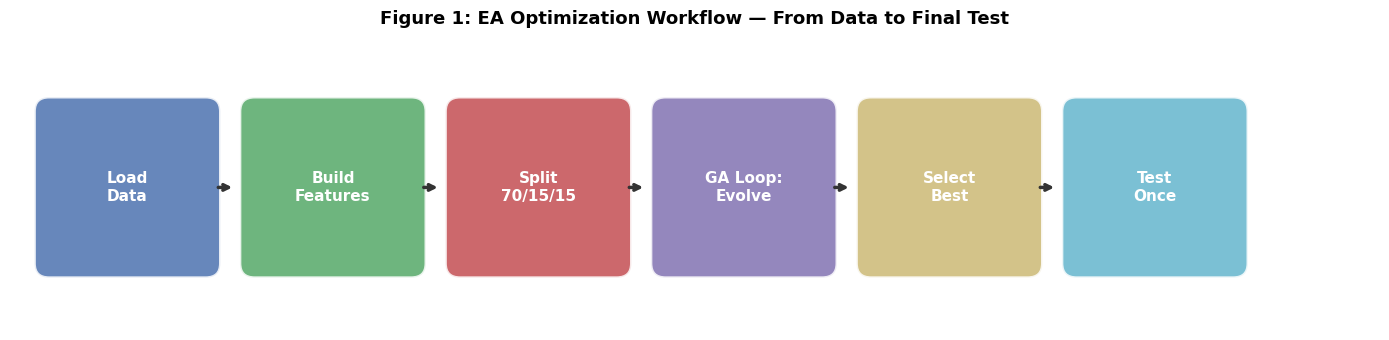

Saved: /home/jovyan/csusb_spring26_cse5140_team1/artifacts/phase2/plots/fig1_ea_workflow.png
Caption: This shows the six main steps. The GA loop (purple) is where evolution happens. The test step (blue) happens only once at the end.


In [17]:
# --- Cell explanation: this cell performs part of the pipeline ---
# Import matplotlib.pyplot as plt so this cell can use that library.
import matplotlib.pyplot as plt
# Import matplotlib.patches as mpatches so this cell can use that library.
import matplotlib.patches as mpatches

# Compute or store a value in `fig, ax` for use later in the notebook.
fig, ax = plt.subplots(figsize=(14, 3.5))
# Create or update a visual output so the result is easier to inspect.
ax.set_xlim(0, 14)
# Create or update a visual output so the result is easier to inspect.
ax.set_ylim(0, 3)
# Create or update a visual output so the result is easier to inspect.
ax.axis('off')
# Create or update a visual output so the result is easier to inspect.
fig.patch.set_facecolor('white')

# Compute or store a value in `steps` for use later in the notebook.
steps = [
    # Execute this line as part of the current analysis step.
    ("Load\nData", "#4C72B0"),
    # Execute this line as part of the current analysis step.
    ("Build\nFeatures", "#55A868"),
    # Execute this line as part of the current analysis step.
    ("Split\n70/15/15", "#C44E52"),
    # Execute this line as part of the current analysis step.
    ("GA Loop:\nEvolve", "#8172B2"),
    # Execute this line as part of the current analysis step.
    ("Select\nBest", "#CCB974"),
    # Execute this line as part of the current analysis step.
    ("Test\nOnce", "#64B5CD"),
# Execute this line as part of the current analysis step.
]

# Loop: iterates over a collection or range
# Loop over i, (label, color) in enumerate(steps) so the same operations are applied repeatedly.
for i, (label, color) in enumerate(steps):
    # Compute or store a value in `x` for use later in the notebook.
    x = 1.2 + i * 2.1
    # Compute or store a value in `rect` for use later in the notebook.
    rect = mpatches.FancyBboxPatch((x - 0.8, 0.7), 1.6, 1.6,
                                    # Compute or store a value in `boxstyle` for use later in the notebook.
                                    boxstyle="round,pad=0.15",
                                    # Compute or store a value in `facecolor` for use later in the notebook.
                                    facecolor=color, edgecolor='white', linewidth=2, alpha=0.85)
    # Create or update a visual output so the result is easier to inspect.
    ax.add_patch(rect)
    # Create or update a visual output so the result is easier to inspect.
    ax.text(x, 1.5, label, ha='center', va='center', fontsize=11, fontweight='bold', color='white')
    # Conditional check: run this block only when i < len(steps) - 1 is true.
    if i < len(steps) - 1:
        # Create or update a visual output so the result is easier to inspect.
        ax.annotate('', xy=(x + 1.1, 1.5), xytext=(x + 0.9, 1.5),
                     # Compute or store a value in `arrowprops` for use later in the notebook.
                     arrowprops=dict(arrowstyle='->', color='#333333', lw=2.5))

# Create or update a visual output so the result is easier to inspect.
ax.set_title("Figure 1: EA Optimization Workflow — From Data to Final Test",
             # Compute or store a value in `fontsize` for use later in the notebook.
             fontsize=13, fontweight='bold', pad=15)

# Create or update a visual output so the result is easier to inspect.
plt.tight_layout()
# Compute or store a value in `fig1_path` for use later in the notebook.
fig1_path = ARTIFACTS_DIR / "plots" / "fig1_ea_workflow.png"
# Create or update a visual output so the result is easier to inspect.
plt.savefig(fig1_path, bbox_inches='tight', dpi=150)
# Create or update a visual output so the result is easier to inspect.
plt.show()
# Print a message or result so the notebook shows useful runtime feedback.
print(f"Saved: {fig1_path.resolve()}")
# Print a message or result so the notebook shows useful runtime feedback.
print("Caption: This shows the six main steps. The GA loop (purple) is where evolution happens. The test step (blue) happens only once at the end.")

## Figure 2: Search Space — What One Candidate Contains

Each candidate (also called an **individual** or **chromosome**) represents one possible set of hyperparameter settings for the neural network.

A **chromosome** is simply a bundle of choices that defines how the model is built and trained.

---

### What a candidate contains

Each candidate includes the following hyperparameters:

- **Learning rate** — how fast the model learns  
- **Dropout** — how much regularization is applied during training  
- **Layers** — the size and structure of the neural network  
- **Weight decay** — an L2 penalty that discourages overly large weights  
- **Batch size** — how many samples are processed at once during training  

---

### Why these search boundaries are reasonable

| Hyperparameter | Search space used | Why this boundary was chosen |
| --- | --- | --- |
| Learning rate | `1e-4` to `1e-2` (log-uniform) | Covers the same order of magnitude as the Phase 1 working rates (`3e-4` to `1e-3`) while allowing one order lower and higher for exploration without jumping to obviously unstable extremes. |
| Dropout | `0.05` to `0.30` | Extends the Phase 1 range (`0.05` to `0.20`) to test slightly stronger regularization without making the network overly noisy. |
| Layers | `(128, 64)`, `(256, 128)`, `(512, 256)` | Keeps the same small / medium / large MLP family already used in Phase 1 so Phase 2 tests search quality rather than architecture redesign. |
| Weight decay | `1e-6` to `1e-3` (log-uniform) | Covers weak-to-moderate L2 regularization and contains the Phase 1 values (`1e-6` to `1e-4`). |
| Batch size | `4096` or `8192` on GPU | Reuses throughput-friendly sizes that were already feasible and stable in the TensorFlow/Keras runs on NRP hardware. |

---

### Example candidate

One candidate might look like:
- `learning_rate = 0.001`
- `dropout = 0.10`
- `layers = (256, 128)`
- `weight_decay = 1e-5`
- `batch_size = 4096`


---

### Why this matters

- Each candidate is one possible configuration the EA can test  
- The search boundaries are **anchored to Phase 1 evidence**, not invented after the fact  
- The chromosome mixes **continuous genes** (learning rate, dropout, weight decay) and **discrete genes** (layers, batch size), which is a natural fit for EA operators  
- Because the model family is intentionally constrained, any gain or loss is easier to attribute to **hyperparameter search** rather than to a hidden architecture change

This search space is deliberately **wide enough to explore, but narrow enough to defend**. That is the key fairness trade-off in Phase 2.


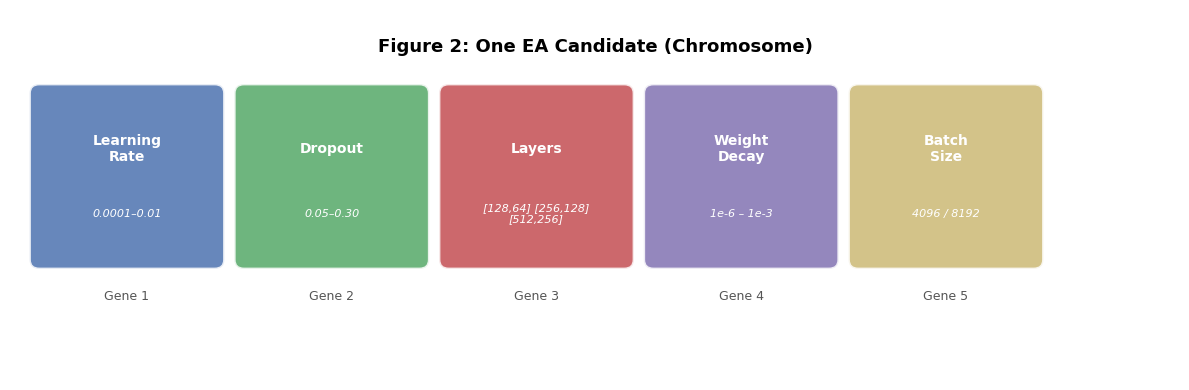

Saved: /home/jovyan/csusb_spring26_cse5140_team1/artifacts/phase2/plots/fig2_chromosome.png
Caption: Each candidate is defined by 5 genes. The GA changes these values through crossover and mutation to find the best combination.


In [18]:
# --- Cell explanation: this cell performs part of the pipeline ---
# Import matplotlib.pyplot as plt so this cell can use that library.
import matplotlib.pyplot as plt
# Import matplotlib.patches as mpatches so this cell can use that library.
import matplotlib.patches as mpatches

# Compute or store a value in `fig, ax` for use later in the notebook.
fig, ax = plt.subplots(figsize=(12, 4))
# Create or update a visual output so the result is easier to inspect.
ax.set_xlim(0, 12)
# Create or update a visual output so the result is easier to inspect.
ax.set_ylim(0, 4)
# Create or update a visual output so the result is easier to inspect.
ax.axis('off')
# Create or update a visual output so the result is easier to inspect.
fig.patch.set_facecolor('white')

# Compute or store a value in `genes` for use later in the notebook.
genes = [
    # Execute this line as part of the current analysis step.
    ("Learning\nRate", "0.0001–0.01", "#4C72B0"),
    # Execute this line as part of the current analysis step.
    ("Dropout", "0.05–0.30", "#55A868"),
    # Execute this line as part of the current analysis step.
    ("Layers", "[128,64] [256,128]\n[512,256]", "#C44E52"),
    # Execute this line as part of the current analysis step.
    ("Weight\nDecay", "1e-6 – 1e-3", "#8172B2"),
    # Execute this line as part of the current analysis step.
    ("Batch\nSize", "4096 / 8192", "#CCB974"),
# Execute this line as part of the current analysis step.
]

# Create or update a visual output so the result is easier to inspect.
ax.text(6, 3.6, "Figure 2: One EA Candidate (Chromosome)", ha='center', va='center',
        # Compute or store a value in `fontsize` for use later in the notebook.
        fontsize=13, fontweight='bold')

# Loop over i, (name, rng, color) in enumerate(genes) so the same operations are applied repeatedly.
for i, (name, rng, color) in enumerate(genes):
    # Compute or store a value in `x` for use later in the notebook.
    x = 1.2 + i * 2.1
    # Compute or store a value in `rect` for use later in the notebook.
    rect = mpatches.FancyBboxPatch((x - 0.9, 1.3), 1.8, 1.8,
                                    # Compute or store a value in `boxstyle` for use later in the notebook.
                                    boxstyle="round,pad=0.1",
                                    # Compute or store a value in `facecolor` for use later in the notebook.
                                    facecolor=color, edgecolor='white', linewidth=2, alpha=0.85)
    # Create or update a visual output so the result is easier to inspect.
    ax.add_patch(rect)
    # Create or update a visual output so the result is easier to inspect.
    ax.text(x, 2.5, name, ha='center', va='center', fontsize=10, fontweight='bold', color='white')
    # Create or update a visual output so the result is easier to inspect.
    ax.text(x, 1.8, rng, ha='center', va='center', fontsize=8, color='white', style='italic')

    # Gene label
    # Create or update a visual output so the result is easier to inspect.
    ax.text(x, 0.9, f"Gene {i+1}", ha='center', va='center', fontsize=9, color='#555555')

# Create or update a visual output so the result is easier to inspect.
plt.tight_layout()
# Compute or store a value in `fig2_path` for use later in the notebook.
fig2_path = ARTIFACTS_DIR / "plots" / "fig2_chromosome.png"
# Create or update a visual output so the result is easier to inspect.
plt.savefig(fig2_path, bbox_inches='tight', dpi=150)
# Create or update a visual output so the result is easier to inspect.
plt.show()
# Print a message or result so the notebook shows useful runtime feedback.
print(f"Saved: {fig2_path.resolve()}")
# Print a message or result so the notebook shows useful runtime feedback.
print("Caption: Each candidate is defined by 5 genes. The GA changes these values through crossover and mutation to find the best combination.")

## Main EA Optimization Cell

> **What this does:** This is the core of the notebook. It defines the neural network, the fitness function, the GA operators (selection, crossover, mutation), and runs the full evolutionary search.  
> **Why it matters:** This is where all optimization happens. Each candidate is trained on the training set, evaluated on the validation set, and improved over generations.  
> **What it saves:** generation logs (CSV), convergence plots (PNG), best model checkpoint (`.keras`), final metrics (CSV), and an environment snapshot (JSON).

---

### How the GA works step by step

1. **Create** a random population of 15 candidates  
2. **Train** each candidate’s neural network using the **training set only**  
3. **Score** each candidate using **validation R² (fitness)**  
4. **Select** parents with **tournament selection (`k = 3`)**  
5. **Crossover** two parents to create a child (mix their settings)  
6. **Mutate** some settings randomly (small changes to keep exploration alive)  
7. **Keep** the top 3 candidates unchanged (elitism)  
8. **Repeat** for 10 generations (fixed compute budget)  
9. **Select** the best overall candidate and evaluate it on the **test set exactly once**

---

### Key rules

- Fitness is computed using the **validation set only**  
- The **test set is never used during optimization**  
- The compute budget (`population = 15`, `generations = 10`) is fixed before the run  
- The operator settings are fixed before the run as well, so the search budget is **not** adjusted after seeing results

---

### Why the EA operators are set this way

| Operator / control | Value used | Why it is reasonable |
| --- | --- | --- |
| Parent selection | Tournament selection (`k = 3`) | Gives moderate selection pressure: better candidates are more likely to reproduce, but weaker candidates are not eliminated as aggressively as they would be in a pure “pick only the top models” strategy. |
| Crossover | `0.80` | Makes recombination the main exploitation mechanism, which is sensible because good hyperparameter blocks can be inherited from different parents. |
| Mutation | `0.30` per gene | Keeps exploration active in a small population and reduces premature convergence, while still preserving much of the parent structure. |
| Elitism | Top `3` kept unchanged | Preserves the best 20% of the population so gains are not lost between generations, while leaving most slots open for exploration. |
| Fitness target | Validation R² | Aligns the EA with the notebook’s primary selection metric. Validation MAPE is still tracked so we can detect when better R² does not translate into lower percentage error. |

---

### Key numbers explained

- `EPOCHS_PER_CANDIDATE = 20` → fixed per-candidate training budget that is large enough to separate weak from viable configurations without dominating total runtime  
- `PATIENCE = 3` → stops candidates that plateau early so the EA does not waste compute on obviously stalled runs  
- `EVAL_BATCH_SIZE = 65536` → large batch size for efficient prediction on GPU  
- `CLIP_MIN_LOG = -2.0`, `CLIP_MAX_LOG = 13.0` → prevents extreme back-transformed predictions  
- `TRAIN_IN_LOG_SPACE = True` → stabilizes training on a highly skewed duration target, while final metrics are still reported on the original scale  

---

### Reproducibility note

The search is still stochastic, but the fixed seed makes the exact search path auditable and rerunnable. That gives us a reproducible EA experiment rather than an uncontrolled random search.


Device: GPU
Artifacts: /home/jovyan/csusb_spring26_cse5140_team1/artifacts/phase2
Saved environment snapshot to: /home/jovyan/csusb_spring26_cse5140_team1/artifacts/phase2/environment_snapshot_phase2.json
NRP image hint: gitlab-registry.nrp-nautilus.io/prp/jupyter-stack/prp-pytorch2:v1.0

EA compute budget:
  Population size : 15
  Generations     : 10
  Theoretical eval: 150
  Mutation rate   : 0.3
  Crossover rate  : 0.8
  Elite count     : 3
  Epochs/candidate: 20


2026-05-02 02:17:33.159380: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-05-02 02:17:33.162430: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-05-02 02:17:33.165678: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-05-02 02:17:33.547529: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-05-02 02:17:33.549121: I tensorflow/compiler/xla/stream_executo


Smoke test candidate:
{'learning_rate': 0.0035311169138214113, 'dropout': 0.1597196099380131, 'layers': (256, 128), 'weight_decay': 0.00012362436879527074, 'batch_size': 8192}
Validation R²   : 0.008049
Validation MAPE : 37.5086%
Generation 01 | best_val_R2=0.009952 | mean_val_R2=0.000434 | best_val_MAPE=34.6801% | mean_val_MAPE=38.4221%
Generation 02 | best_val_R2=0.009952 | mean_val_R2=0.008109 | best_val_MAPE=32.4131% | mean_val_MAPE=35.7075%
Generation 03 | best_val_R2=0.009952 | mean_val_R2=0.007719 | best_val_MAPE=34.6801% | mean_val_MAPE=36.9628%
Generation 04 | best_val_R2=0.010019 | mean_val_R2=0.008949 | best_val_MAPE=34.3048% | mean_val_MAPE=36.5803%
Generation 05 | best_val_R2=0.010019 | mean_val_R2=0.003737 | best_val_MAPE=33.5563% | mean_val_MAPE=36.5525%
Generation 06 | best_val_R2=0.010019 | mean_val_R2=0.009579 | best_val_MAPE=33.5588% | mean_val_MAPE=36.1132%
Generation 07 | best_val_R2=0.010019 | mean_val_R2=0.009055 | best_val_MAPE=33.4837% | mean_val_MAPE=36.5383%

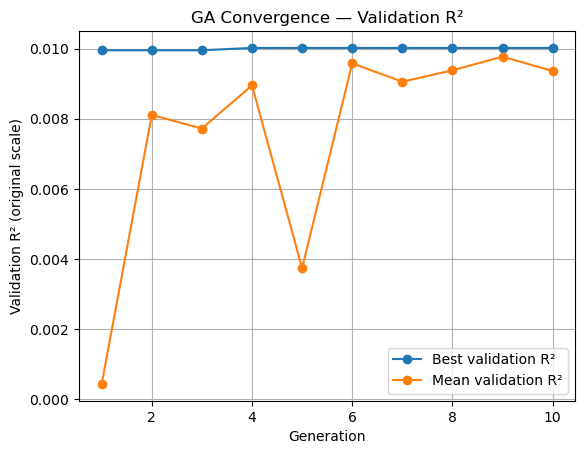

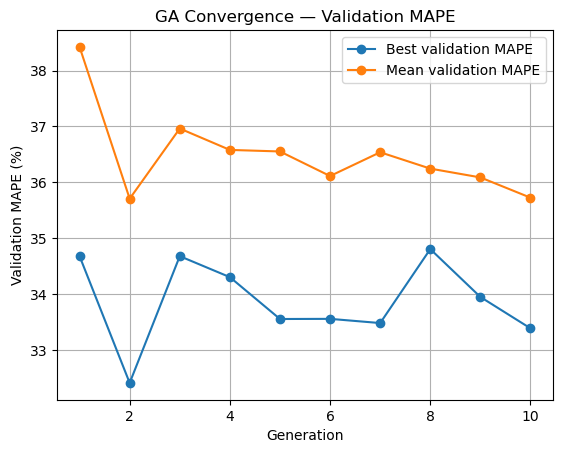

Saved plots:
  /home/jovyan/csusb_spring26_cse5140_team1/artifacts/phase2/plots/ga_convergence_r2.png
  /home/jovyan/csusb_spring26_cse5140_team1/artifacts/phase2/plots/ga_convergence_mape.png

=== Final Best Individual ===
{'learning_rate': 0.00461869838886613, 'dropout': 0.08493812090232745, 'layers': (512, 256), 'weight_decay': 1.0521721669668518e-06, 'batch_size': 4096}

=== Validation Metrics (Best EA Candidate) ===
r2: 0.009568
rmse: 5912.946418
mae: 348.403556
mape: 35.0641%
r2_log: 0.671484
rmse_log: 0.453942
mae_log: 0.303467

=== Test Metrics (Final One-Time Evaluation) ===
r2: -0.115639
rmse: 3215.877764
mae: 327.934266
mape: 35.2028%
r2_log: 0.674821
rmse_log: 0.451894
mae_log: 0.303059

Saved final artifacts:
  /home/jovyan/csusb_spring26_cse5140_team1/artifacts/phase2/ea_final_metrics.csv
  /home/jovyan/csusb_spring26_cse5140_team1/artifacts/phase2/best_ea_individual.json
  /home/jovyan/csusb_spring26_cse5140_team1/artifacts/phase2/best_ea_model.keras

=== Compute Summary

In [19]:
# --- Cell explanation: this cell performs part of the pipeline ---
# ============================================================
# Phase 2 — EA Optimization (TensorFlow/Keras, single-GPU, compliant version)
# Primary EA fitness: validation R² on ORIGINAL scale
# Secondary tracked metric: validation MAPE on ORIGINAL scale
# Training target: log1p(duration) for stability (fitness/reporting
#                  are still on original scale)
# ============================================================

# Import os so this cell can use that library.
import os
# Import sys so this cell can use that library.
import sys
# Import time so this cell can use that library.
import time
# Import json so this cell can use that library.
import json
# Import copy so this cell can use that library.
import copy
# Import random so this cell can use that library.
import random
# Import gc so this cell can use that library.
import gc
# Import platform so this cell can use that library.
import platform
# Import subprocess so this cell can use that library.
import subprocess
# Import hashlib so this cell can use that library.
import hashlib
# Import specific tools from pathlib for use below.
from pathlib import Path

# Import numpy as np so this cell can use that library.
import numpy as np
# Import pandas as pd so this cell can use that library.
import pandas as pd
# Import matplotlib.pyplot as plt so this cell can use that library.
import matplotlib.pyplot as plt
# Import tensorflow as tf so this cell can use that library.
import tensorflow as tf
# Import specific tools from tensorflow.keras for use below.
from tensorflow.keras import Sequential
# Import specific tools from tensorflow.keras.layers for use below.
from tensorflow.keras.layers import Dense, Dropout, Input
# Import specific tools from tensorflow.keras for use below.
from tensorflow.keras import regularizers
# Import specific tools from sklearn.metrics for use below.
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ------------------------------------------------------------
# 0) Sanity checks: required objects from earlier cells
# ------------------------------------------------------------
# Compute or store a value in `required_names` for use later in the notebook.
required_names = [
    # Execute this line as part of the current analysis step.
    "SEED", "ARTIFACTS_DIR", "device",
    # Execute this line as part of the current analysis step.
    "X_train_s", "X_val_s", "X_test_s",
    # Execute this line as part of the current analysis step.
    "y_train_orig", "y_val_orig", "y_test_orig",
    # Execute this line as part of the current analysis step.
    "y_train_log", "y_val_log", "y_test_log",
    # Execute this line as part of the current analysis step.
    "log_generation_stats",
    # Execute this line as part of the current analysis step.
    "POPULATION_SIZE", "GENERATIONS",
    # Execute this line as part of the current analysis step.
    "MUTATION_RATE", "CROSSOVER_RATE", "ELITE_COUNT",
    # Execute this line as part of the current analysis step.
    "EPOCHS_PER_CANDIDATE", "PATIENCE", "TOTAL_EVALUATIONS",
# Execute this line as part of the current analysis step.
]
# Compute or store a value in `missing` for use later in the notebook.
missing = [name for name in required_names if name not in globals()]
# Conditional check: run this block only when missing is true.
if missing:
    # Raise an error here so execution stops when the required condition is not met.
    raise NameError(f"Missing required variables from earlier cells: {missing}")

# Compute or store a value in `ARTIFACTS_DIR` for use later in the notebook.
ARTIFACTS_DIR = Path(ARTIFACTS_DIR)
# Create the directory if needed so later files can be written safely.
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
# Compute or store a value in `PLOTS_DIR` for use later in the notebook.
PLOTS_DIR = ARTIFACTS_DIR / "plots"
# Compute or store a value in `LOG_DIR` for use later in the notebook.
LOG_DIR = ARTIFACTS_DIR / "ea_trial_logs"
# Create the directory if needed so later files can be written safely.
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
# Create the directory if needed so later files can be written safely.
LOG_DIR.mkdir(parents=True, exist_ok=True)

# Print a message or result so the notebook shows useful runtime feedback.
print("Device:", device)
# Print a message or result so the notebook shows useful runtime feedback.
print("Artifacts:", ARTIFACTS_DIR.resolve())

# ------------------------------------------------------------
# 1) NRP / environment snapshot (auditable evidence)
# ------------------------------------------------------------
# Define the function `_safe_cmd` so this logic can be reused later.
def _safe_cmd(cmd):
    # Try branch: handle the alternate or cleanup path.
    try:
        # Return the computed value so the caller can use it.
        return subprocess.check_output(cmd, text=True, stderr=subprocess.STDOUT)
    # Execute this line as part of the current analysis step.
    except Exception as e:
        # Return the computed value so the caller can use it.
        return f"(command failed: {cmd} -> {e})\n"

# Compute or store a value in `image_hint` for use later in the notebook.
image_hint = (
    # Execute this line as part of the current analysis step.
    os.environ.get("JUPYTER_IMAGE_SPEC")
    # Execute this line as part of the current analysis step.
    or os.environ.get("CONTAINER_IMAGE")
    # Execute this line as part of the current analysis step.
    or os.environ.get("JUPYTERHUB_IMAGE")
    # Execute this line as part of the current analysis step.
    or os.environ.get("IMAGE_NAME")
    # Execute this line as part of the current analysis step.
    or "UNKNOWN"
# Execute this line as part of the current analysis step.
)

# Compute or store a value in `gpus` for use later in the notebook.
gpus = tf.config.list_physical_devices("GPU")
# Compute or store a value in `gpu_names` for use later in the notebook.
gpu_names = [gpu.name for gpu in gpus]
# Compute or store a value in `env_snapshot` for use later in the notebook.
env_snapshot = {
    # Execute this line as part of the current analysis step.
    "timestamp": pd.Timestamp.now().isoformat(),
    # Execute this line as part of the current analysis step.
    "platform": platform.platform(),
    # Execute this line as part of the current analysis step.
    "python_version": sys.version.replace("\n", " "),
    # Execute this line as part of the current analysis step.
    "python_executable": sys.executable,
    # Execute this line as part of the current analysis step.
    "tensorflow_version": tf.__version__,
    # Execute this line as part of the current analysis step.
    "device": str(device),
    # Execute this line as part of the current analysis step.
    "gpu_count": int(len(gpus)),
    # Execute this line as part of the current analysis step.
    "gpu_names": gpu_names,
    # Execute this line as part of the current analysis step.
    "nrp_image_hint": image_hint,
# Execute this line as part of the current analysis step.
}
# Compute or store a value in `env_path` for use later in the notebook.
env_path = ARTIFACTS_DIR / "environment_snapshot_phase2.json"
# Save the generated result to disk so it can be reused later.
env_path.write_text(json.dumps(env_snapshot, indent=2), encoding="utf-8")

# Print a message or result so the notebook shows useful runtime feedback.
print("Saved environment snapshot to:", env_path.resolve())
# Print a message or result so the notebook shows useful runtime feedback.
print("NRP image hint:", image_hint)

# ------------------------------------------------------------
# 2) TensorFlow single-GPU / evaluation controls
# ------------------------------------------------------------
# Compute or store a value in `USE_GPU` for use later in the notebook.
USE_GPU = len(gpus) > 0
# Compute or store a value in `GPU_COUNT` for use later in the notebook.
GPU_COUNT = len(gpus)
# Compute or store a value in `EVAL_BATCH_SIZE` for use later in the notebook.
EVAL_BATCH_SIZE = 65536 if USE_GPU else 16384

# ------------------------------------------------------------
# 3) Reproducibility helpers
# ------------------------------------------------------------
# Define the function `seed_everything` so this logic can be reused later.
def seed_everything(seed=SEED):
    # Compute or store a value in `os.environ["PYTHONHASHSEED"]` for use later in the notebook.
    os.environ["PYTHONHASHSEED"] = str(seed)
    # Execute this line as part of the current analysis step.
    random.seed(seed)
    # Execute this line as part of the current analysis step.
    np.random.seed(seed)
    # Execute this line as part of the current analysis step.
    tf.keras.utils.set_random_seed(seed)

# Execute this line as part of the current analysis step.
seed_everything(SEED)

# ------------------------------------------------------------
# 4) Metrics + target handling
# ------------------------------------------------------------
# Compute or store a value in `TRAIN_IN_LOG_SPACE` for use later in the notebook.
TRAIN_IN_LOG_SPACE = True
# Compute or store a value in `CLIP_MIN_LOG` for use later in the notebook.
CLIP_MIN_LOG = -2.0
# Compute or store a value in `CLIP_MAX_LOG` for use later in the notebook.
CLIP_MAX_LOG = 13.0

# Define the function `safe_expm1` so this logic can be reused later.
def safe_expm1(yhat_log, clip_min=CLIP_MIN_LOG, clip_max=CLIP_MAX_LOG):
    # Compute or store a value in `yhat_log` for use later in the notebook.
    yhat_log = np.asarray(yhat_log).reshape(-1)
    # Compute or store a value in `yhat_log` for use later in the notebook.
    yhat_log = np.clip(yhat_log, clip_min, clip_max)
    # Return the computed value so the caller can use it.
    return np.expm1(yhat_log)

# Define the function `mape` so this logic can be reused later.
def mape(y_true, y_pred, eps=1.0):
    # Compute or store a value in `y_true` for use later in the notebook.
    y_true = np.asarray(y_true).reshape(-1).astype(np.float64)
    # Compute or store a value in `y_pred` for use later in the notebook.
    y_pred = np.asarray(y_pred).reshape(-1).astype(np.float64)
    # Compute or store a value in `denom` for use later in the notebook.
    denom = np.maximum(np.abs(y_true), eps)
    # Return the computed value so the caller can use it.
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100.0)

# Define the function `regression_metrics_original` so this logic can be reused later.
def regression_metrics_original(y_true_orig, y_pred_orig):
    # Return the computed value so the caller can use it.
    return {
        # Execute this line as part of the current analysis step.
        "r2": float(r2_score(y_true_orig, y_pred_orig)),
        # Compute or store a value in `"rmse": float(mean_squared_error(y_true_orig, y_pred_orig, squared` for use later in the notebook.
        "rmse": float(mean_squared_error(y_true_orig, y_pred_orig, squared=False)),
        # Execute this line as part of the current analysis step.
        "mae": float(mean_absolute_error(y_true_orig, y_pred_orig)),
        # Execute this line as part of the current analysis step.
        "mape": float(mape(y_true_orig, y_pred_orig)),
    # Execute this line as part of the current analysis step.
    }

# Define the function `regression_metrics_log` so this logic can be reused later.
def regression_metrics_log(y_true_log, y_pred_log):
    # Return the computed value so the caller can use it.
    return {
        # Execute this line as part of the current analysis step.
        "r2_log": float(r2_score(y_true_log, y_pred_log)),
        # Compute or store a value in `"rmse_log": float(mean_squared_error(y_true_log, y_pred_log, squared` for use later in the notebook.
        "rmse_log": float(mean_squared_error(y_true_log, y_pred_log, squared=False)),
        # Execute this line as part of the current analysis step.
        "mae_log": float(mean_absolute_error(y_true_log, y_pred_log)),
    # Execute this line as part of the current analysis step.
    }

# ------------------------------------------------------------
# 5) Shared NumPy arrays
# ------------------------------------------------------------
# Compute or store a value in `X_train_np` for use later in the notebook.
X_train_np = X_train_s.to_numpy(dtype=np.float32)
# Compute or store a value in `X_val_np` for use later in the notebook.
X_val_np   = X_val_s.to_numpy(dtype=np.float32)
# Compute or store a value in `X_test_np` for use later in the notebook.
X_test_np  = X_test_s.to_numpy(dtype=np.float32)

# Training target can be log-space, but fitness/reporting remain original-scale.
# Compute or store a value in `y_train_fit` for use later in the notebook.
y_train_fit = y_train_log if TRAIN_IN_LOG_SPACE else y_train_orig
# Compute or store a value in `y_val_fit` for use later in the notebook.
y_val_fit   = y_val_log if TRAIN_IN_LOG_SPACE else y_val_orig
# Compute or store a value in `y_test_fit` for use later in the notebook.
y_test_fit  = y_test_log if TRAIN_IN_LOG_SPACE else y_test_orig

# Compute or store a value in `y_train_fit_np` for use later in the notebook.
y_train_fit_np = np.asarray(y_train_fit, dtype=np.float32).reshape(-1, 1)
# Compute or store a value in `y_val_fit_np` for use later in the notebook.
y_val_fit_np   = np.asarray(y_val_fit, dtype=np.float32).reshape(-1, 1)
# Compute or store a value in `y_test_fit_np` for use later in the notebook.
y_test_fit_np  = np.asarray(y_test_fit, dtype=np.float32).reshape(-1, 1)

# ------------------------------------------------------------
# 6) Model / individual encoding
# ------------------------------------------------------------
# Compute or store a value in `SEARCH_SPACE` for use later in the notebook.
SEARCH_SPACE = {
    # Execute this line as part of the current analysis step.
    "learning_rate": (1e-4, 1e-2),
    # Execute this line as part of the current analysis step.
    "dropout": (0.05, 0.30),
    # Execute this line as part of the current analysis step.
    "layers": [(128, 64), (256, 128), (512, 256)],
    # Execute this line as part of the current analysis step.
    "weight_decay": (1e-6, 1e-3),
    # Execute this line as part of the current analysis step.
    "batch_size": [4096, 8192] if USE_GPU else [1024, 2048],
# Execute this line as part of the current analysis step.
}

# Print a message or result so the notebook shows useful runtime feedback.
print("\nEA compute budget:")
# Print a message or result so the notebook shows useful runtime feedback.
print("  Population size :", POPULATION_SIZE)
# Print a message or result so the notebook shows useful runtime feedback.
print("  Generations     :", GENERATIONS)
# Print a message or result so the notebook shows useful runtime feedback.
print("  Theoretical eval:", TOTAL_EVALUATIONS)
# Print a message or result so the notebook shows useful runtime feedback.
print("  Mutation rate   :", MUTATION_RATE)
# Print a message or result so the notebook shows useful runtime feedback.
print("  Crossover rate  :", CROSSOVER_RATE)
# Print a message or result so the notebook shows useful runtime feedback.
print("  Elite count     :", ELITE_COUNT)
# Print a message or result so the notebook shows useful runtime feedback.
print("  Epochs/candidate:", EPOCHS_PER_CANDIDATE)

# Define the function `sample_log_uniform` so this logic can be reused later.
def sample_log_uniform(low, high, rng):
    # Return the computed value so the caller can use it.
    return float(np.exp(rng.uniform(np.log(low), np.log(high))))

# Define the function `create_individual` so this logic can be reused later.
def create_individual(rng=None):
    # Compute or store a value in `rng` for use later in the notebook.
    rng = np.random.default_rng(SEED) if rng is None else rng
    # Return the computed value so the caller can use it.
    return {
        # Compute or store a value in `"learning_rate": sample_log_uniform(*SEARCH_SPACE["learning_rate"], rng` for use later in the notebook.
        "learning_rate": sample_log_uniform(*SEARCH_SPACE["learning_rate"], rng=rng),
        # Execute this line as part of the current analysis step.
        "dropout": float(rng.uniform(*SEARCH_SPACE["dropout"])),
        # Execute this line as part of the current analysis step.
        "layers": tuple(SEARCH_SPACE["layers"][int(rng.integers(0, len(SEARCH_SPACE["layers"])))]),
        # Compute or store a value in `"weight_decay": sample_log_uniform(*SEARCH_SPACE["weight_decay"], rng` for use later in the notebook.
        "weight_decay": sample_log_uniform(*SEARCH_SPACE["weight_decay"], rng=rng),
        # Execute this line as part of the current analysis step.
        "batch_size": int(SEARCH_SPACE["batch_size"][int(rng.integers(0, len(SEARCH_SPACE["batch_size"])))]),
    # Execute this line as part of the current analysis step.
    }

# Define the function `individual_key` so this logic can be reused later.
def individual_key(individual):
    # Return the computed value so the caller can use it.
    return (
        # Execute this line as part of the current analysis step.
        round(float(individual["learning_rate"]), 10),
        # Execute this line as part of the current analysis step.
        round(float(individual["dropout"]), 6),
        # Execute this line as part of the current analysis step.
        tuple(individual["layers"]),
        # Execute this line as part of the current analysis step.
        round(float(individual["weight_decay"]), 10),
        # Execute this line as part of the current analysis step.
        int(individual["batch_size"]),
    # Execute this line as part of the current analysis step.
    )

# Define the function `stable_individual_id` so this logic can be reused later.
def stable_individual_id(individual):
    # Compute or store a value in `payload` for use later in the notebook.
    payload = json.dumps(
        # Execute this line as part of the current analysis step.
        {
            # Execute this line as part of the current analysis step.
            "learning_rate": float(individual["learning_rate"]),
            # Execute this line as part of the current analysis step.
            "dropout": float(individual["dropout"]),
            # Execute this line as part of the current analysis step.
            "layers": list(individual["layers"]),
            # Execute this line as part of the current analysis step.
            "weight_decay": float(individual["weight_decay"]),
            # Execute this line as part of the current analysis step.
            "batch_size": int(individual["batch_size"]),
        # Execute this line as part of the current analysis step.
        },
        # Compute or store a value in `sort_keys` for use later in the notebook.
        sort_keys=True,
    # Execute this line as part of the current analysis step.
    )
    # Return the computed value so the caller can use it.
    return hashlib.md5(payload.encode("utf-8")).hexdigest()[:12]

# Define the function `build_model_from_individual` so this logic can be reused later.
def build_model_from_individual(individual, in_dim):
    # Compute or store a value in `reg` for use later in the notebook.
    reg = regularizers.l2(float(individual["weight_decay"])) if float(individual["weight_decay"]) > 0 else None
    # Compute or store a value in `model` for use later in the notebook.
    model = Sequential(name="ea_candidate_model")
    # Compute or store a value in `model.add(Input(shape` for use later in the notebook.
    model.add(Input(shape=(in_dim,)))

    # Loop over h in individual["layers"] so the same operations are applied repeatedly.
    for h in individual["layers"]:
        # Compute or store a value in `model.add(Dense(int(h), activation` for use later in the notebook.
        model.add(Dense(int(h), activation="relu", kernel_regularizer=reg))
        # Execute this line as part of the current analysis step.
        model.add(Dropout(float(individual["dropout"])))

    # Execute this line as part of the current analysis step.
    model.add(Dense(1))
    # Return the computed value so the caller can use it.
    return model

# ------------------------------------------------------------
# 7) Prediction helpers
# ------------------------------------------------------------
# Define the function `model_predict_fit_space` so this logic can be reused later.
def model_predict_fit_space(model, X_np, batch_size=EVAL_BATCH_SIZE):
    # Generate predictions from the current model using the provided inputs.
    preds = model.predict(np.asarray(X_np, dtype=np.float32), batch_size=batch_size, verbose=0).reshape(-1)
    # Conditional check: run this block only when TRAIN_IN_LOG_SPACE is true.
    if TRAIN_IN_LOG_SPACE:
        # Compute or store a value in `preds` for use later in the notebook.
        preds = np.clip(preds, CLIP_MIN_LOG, CLIP_MAX_LOG)
    # Return the computed value so the caller can use it.
    return preds

# Define the function `fit_to_original_scale` so this logic can be reused later.
def fit_to_original_scale(pred_fit):
    # Conditional check: run this block only when TRAIN_IN_LOG_SPACE is true.
    if TRAIN_IN_LOG_SPACE:
        # Return the computed value so the caller can use it.
        return safe_expm1(pred_fit)
    # Return the computed value so the caller can use it.
    return np.maximum(pred_fit, 0.0)

# Define the function `model_predict_original` so this logic can be reused later.
def model_predict_original(model, X_np):
    # Compute or store a value in `pred_fit` for use later in the notebook.
    pred_fit = model_predict_fit_space(model, X_np)
    # Return the computed value so the caller can use it.
    return fit_to_original_scale(pred_fit)

# ------------------------------------------------------------
# 8) Train/evaluate one candidate
# ------------------------------------------------------------
# Define the function `evaluate_candidate` so this logic can be reused later.
def evaluate_candidate(individual, trial_seed, return_model=False):
    # Start a documentation string that explains the block below.
    """
    # Execute this line as part of the current analysis step.
    Train on TRAIN only.
    # Execute this line as part of the current analysis step.
    Select epoch by VALIDATION R² on ORIGINAL scale.
    # Execute this line as part of the current analysis step.
    Return both primary metric (val_r2) and secondary metric (val_mape).
    # Start a documentation string that explains the block below.
    """
    # Execute this line as part of the current analysis step.
    tf.keras.backend.clear_session()
    # Execute this line as part of the current analysis step.
    gc.collect()
    # Execute this line as part of the current analysis step.
    seed_everything(trial_seed)

    # Compute or store a value in `model` for use later in the notebook.
    model = build_model_from_individual(individual, in_dim=X_train_np.shape[1])
    # Configure the model's optimizer and loss before training starts.
    model.compile(
        # Compute or store a value in `optimizer` for use later in the notebook.
        optimizer=tf.keras.optimizers.Adam(learning_rate=float(individual["learning_rate"])),
        # Compute or store a value in `loss` for use later in the notebook.
        loss=tf.keras.losses.Huber(delta=0.5) if TRAIN_IN_LOG_SPACE else "mse",
    # Execute this line as part of the current analysis step.
    )

    # Compute or store a value in `best_weights` for use later in the notebook.
    best_weights = None
    # Compute or store a value in `best_epoch` for use later in the notebook.
    best_epoch = 0
    # Compute or store a value in `best_val_r2` for use later in the notebook.
    best_val_r2 = -np.inf
    # Compute or store a value in `best_epoch_metrics` for use later in the notebook.
    best_epoch_metrics = None
    # Compute or store a value in `patience_counter` for use later in the notebook.
    patience_counter = 0
    # Compute or store a value in `history` for use later in the notebook.
    history = []

    # Loop over epoch in range(1, EPOCHS_PER_CANDIDATE + 1) so the same operations are applied repeatedly.
    for epoch in range(1, EPOCHS_PER_CANDIDATE + 1):
        # Fit or train the model using the prepared input data.
        hist = model.fit(
            # Execute this line as part of the current analysis step.
            X_train_np,
            # Execute this line as part of the current analysis step.
            y_train_fit_np,
            # Compute or store a value in `epochs` for use later in the notebook.
            epochs=1,
            # Compute or store a value in `batch_size` for use later in the notebook.
            batch_size=int(individual["batch_size"]),
            # Compute or store a value in `shuffle` for use later in the notebook.
            shuffle=True,
            # Compute or store a value in `verbose` for use later in the notebook.
            verbose=0,
        # Execute this line as part of the current analysis step.
        )
        # Compute or store a value in `train_loss` for use later in the notebook.
        train_loss = float(hist.history["loss"][0])

        # Compute or store a value in `val_pred_fit` for use later in the notebook.
        val_pred_fit = model_predict_fit_space(model, X_val_np)
        # Compute or store a value in `val_pred_orig` for use later in the notebook.
        val_pred_orig = fit_to_original_scale(val_pred_fit)

        # Compute or store a value in `val_metrics_orig` for use later in the notebook.
        val_metrics_orig = regression_metrics_original(y_val_orig, val_pred_orig)
        # Compute or store a value in `val_metrics_log` for use later in the notebook.
        val_metrics_log = regression_metrics_log(y_val_log, val_pred_fit)

        # Compute or store a value in `row` for use later in the notebook.
        row = {
            # Execute this line as part of the current analysis step.
            "epoch": epoch,
            # Execute this line as part of the current analysis step.
            "train_loss": train_loss,
            # Execute this line as part of the current analysis step.
            **{f"val_{k}": v for k, v in val_metrics_orig.items()},
            # Execute this line as part of the current analysis step.
            **{f"val_{k}": v for k, v in val_metrics_log.items()},
        # Execute this line as part of the current analysis step.
        }
        # Execute this line as part of the current analysis step.
        history.append(row)

        # Conditional check: run this block only when val_metrics_orig["r2"] > best_val_r2 + 1e-6 is true.
        if val_metrics_orig["r2"] > best_val_r2 + 1e-6:
            # Compute or store a value in `best_val_r2` for use later in the notebook.
            best_val_r2 = val_metrics_orig["r2"]
            # Compute or store a value in `best_epoch` for use later in the notebook.
            best_epoch = epoch
            # Compute or store a value in `best_epoch_metrics` for use later in the notebook.
            best_epoch_metrics = {
                # Execute this line as part of the current analysis step.
                **val_metrics_orig,
                # Execute this line as part of the current analysis step.
                **val_metrics_log,
            # Execute this line as part of the current analysis step.
            }
            # Compute or store a value in `best_weights` for use later in the notebook.
            best_weights = model.get_weights()
            # Compute or store a value in `patience_counter` for use later in the notebook.
            patience_counter = 0
        # Else branch: handle the alternate or cleanup path.
        else:
            # Compute or store a value in `patience_counter +` for use later in the notebook.
            patience_counter += 1
            # Conditional check: run this block only when patience_counter >= PATIENCE is true.
            if patience_counter >= PATIENCE:
                # Execute this line as part of the current analysis step.
                break

    # Conditional check: run this block only when best_weights is None is true.
    if best_weights is None:
        # Raise an error here so execution stops when the required condition is not met.
        raise RuntimeError("No valid state captured during candidate evaluation.")

    # Execute this line as part of the current analysis step.
    model.set_weights(best_weights)

    # Compute or store a value in `hist_path` for use later in the notebook.
    hist_path = LOG_DIR / f"candidate_{stable_individual_id(individual)}_{trial_seed}.csv"
    # Save the generated result to disk so it can be reused later.
    pd.DataFrame(history).to_csv(hist_path, index=False)

    # Compute or store a value in `result` for use later in the notebook.
    result = {
        # Execute this line as part of the current analysis step.
        "best_epoch": int(best_epoch),
        # Execute this line as part of the current analysis step.
        "history_csv": str(hist_path),
        # Execute this line as part of the current analysis step.
        "val_r2": float(best_epoch_metrics["r2"]),
        # Execute this line as part of the current analysis step.
        "val_rmse": float(best_epoch_metrics["rmse"]),
        # Execute this line as part of the current analysis step.
        "val_mae": float(best_epoch_metrics["mae"]),
        # Execute this line as part of the current analysis step.
        "val_mape": float(best_epoch_metrics["mape"]),
        # Execute this line as part of the current analysis step.
        "val_r2_log": float(best_epoch_metrics["r2_log"]),
        # Execute this line as part of the current analysis step.
        "val_rmse_log": float(best_epoch_metrics["rmse_log"]),
        # Execute this line as part of the current analysis step.
        "val_mae_log": float(best_epoch_metrics["mae_log"]),
    # Execute this line as part of the current analysis step.
    }
    # Conditional check: run this block only when return_model is true.
    if return_model:
        # Compute or store a value in `result["model"]` for use later in the notebook.
        result["model"] = model
    # Else branch: handle the alternate or cleanup path.
    else:
        # Delete the temporary object to free memory before continuing.
        del model
        # Execute this line as part of the current analysis step.
        gc.collect()
    # Return the computed value so the caller can use it.
    return result

# ------------------------------------------------------------
# 9) GA operators
# ------------------------------------------------------------
# Define the function `initialize_population` so this logic can be reused later.
def initialize_population(size, seed=SEED):
    # Compute or store a value in `rng` for use later in the notebook.
    rng = np.random.default_rng(seed)
    # Return the computed value so the caller can use it.
    return [create_individual(rng) for _ in range(size)]

# Define the function `tournament_selection` so this logic can be reused later.
def tournament_selection(population, metrics_list, k=3, seed=None):
    # Compute or store a value in `rng` for use later in the notebook.
    rng = np.random.default_rng(seed)
    # Compute or store a value in `idxs` for use later in the notebook.
    idxs = rng.choice(len(population), size=k, replace=False)
    # Compute or store a value in `best_idx` for use later in the notebook.
    best_idx = max(idxs, key=lambda i: metrics_list[i]["val_r2"])
    # Return the computed value so the caller can use it.
    return copy.deepcopy(population[best_idx])

# Define the function `crossover` so this logic can be reused later.
def crossover(parent1, parent2, seed=None):
    # Compute or store a value in `rng` for use later in the notebook.
    rng = np.random.default_rng(seed)
    # Compute or store a value in `child` for use later in the notebook.
    child = {}
    # Loop over key in parent1.keys() so the same operations are applied repeatedly.
    for key in parent1.keys():
        # Compute or store a value in `child[key]` for use later in the notebook.
        child[key] = copy.deepcopy(parent1[key] if rng.random() < 0.5 else parent2[key])
    # Return the computed value so the caller can use it.
    return child

# Define the function `mutate` so this logic can be reused later.
def mutate(individual, mutation_rate=MUTATION_RATE, seed=None):
    # Compute or store a value in `rng` for use later in the notebook.
    rng = np.random.default_rng(seed)
    # Compute or store a value in `child` for use later in the notebook.
    child = copy.deepcopy(individual)

    # Conditional check: run this block only when rng.random() < mutation_rate is true.
    if rng.random() < mutation_rate:
        # Compute or store a value in `child["learning_rate"]` for use later in the notebook.
        child["learning_rate"] = sample_log_uniform(*SEARCH_SPACE["learning_rate"], rng=rng)
    # Conditional check: run this block only when rng.random() < mutation_rate is true.
    if rng.random() < mutation_rate:
        # Compute or store a value in `child["dropout"]` for use later in the notebook.
        child["dropout"] = float(rng.uniform(*SEARCH_SPACE["dropout"]))
    # Conditional check: run this block only when rng.random() < mutation_rate is true.
    if rng.random() < mutation_rate:
        # Compute or store a value in `child["layers"]` for use later in the notebook.
        child["layers"] = tuple(SEARCH_SPACE["layers"][int(rng.integers(0, len(SEARCH_SPACE["layers"])))])
    # Conditional check: run this block only when rng.random() < mutation_rate is true.
    if rng.random() < mutation_rate:
        # Compute or store a value in `child["weight_decay"]` for use later in the notebook.
        child["weight_decay"] = sample_log_uniform(*SEARCH_SPACE["weight_decay"], rng=rng)
    # Conditional check: run this block only when rng.random() < mutation_rate is true.
    if rng.random() < mutation_rate:
        # Compute or store a value in `child["batch_size"]` for use later in the notebook.
        child["batch_size"] = int(SEARCH_SPACE["batch_size"][int(rng.integers(0, len(SEARCH_SPACE["batch_size"])))])

    # Return the computed value so the caller can use it.
    return child

# ------------------------------------------------------------
# 10) Fitness cache + fitness function
# ------------------------------------------------------------
# Compute or store a value in `fitness_cache` for use later in the notebook.
fitness_cache = {}
# Compute or store a value in `fitness_calls` for use later in the notebook.
fitness_calls = 0

# Define the function `fitness` so this logic can be reused later.
def fitness(individual, eval_id):
    # Start a documentation string that explains the block below.
    """
    # Execute this line as part of the current analysis step.
    Authoritative EA fitness.
    # Execute this line as part of the current analysis step.
    Returns PRIMARY metric only: validation R² on ORIGINAL scale.
    # Execute this line as part of the current analysis step.
    Secondary metric (validation MAPE) is also computed and cached.
    # Start a documentation string that explains the block below.
    """
    # Execute this line as part of the current analysis step.
    global fitness_calls

    # Compute or store a value in `key` for use later in the notebook.
    key = individual_key(individual)
    # Conditional check: run this block only when key not in fitness_cache is true.
    if key not in fitness_cache:
        # Compute or store a value in `fitness_calls +` for use later in the notebook.
        fitness_calls += 1
        # Compute or store a value in `result` for use later in the notebook.
        result = evaluate_candidate(individual, trial_seed=SEED + eval_id, return_model=False)
        # Compute or store a value in `fitness_cache[key]` for use later in the notebook.
        fitness_cache[key] = {
            # Execute this line as part of the current analysis step.
            "val_r2": result["val_r2"],
            # Execute this line as part of the current analysis step.
            "val_mape": result["val_mape"],
            # Execute this line as part of the current analysis step.
            "best_epoch": result["best_epoch"],
            # Execute this line as part of the current analysis step.
            "val_rmse": result["val_rmse"],
            # Execute this line as part of the current analysis step.
            "val_mae": result["val_mae"],
            # Execute this line as part of the current analysis step.
            "val_r2_log": result["val_r2_log"],
            # Execute this line as part of the current analysis step.
            "val_rmse_log": result["val_rmse_log"],
            # Execute this line as part of the current analysis step.
            "val_mae_log": result["val_mae_log"],
            # Execute this line as part of the current analysis step.
            "history_csv": result["history_csv"],
        # Execute this line as part of the current analysis step.
        }

    # Return the computed value so the caller can use it.
    return fitness_cache[key]["val_r2"]

# Define the function `get_cached_metrics` so this logic can be reused later.
def get_cached_metrics(individual):
    # Compute or store a value in `key` for use later in the notebook.
    key = individual_key(individual)
    # Conditional check: run this block only when key not in fitness_cache is true.
    if key not in fitness_cache:
        # Raise an error here so execution stops when the required condition is not met.
        raise ValueError("Individual not found in fitness_cache")
    # Return the computed value so the caller can use it.
    return fitness_cache[key]

# ------------------------------------------------------------
# 11) Smoke test
# ------------------------------------------------------------
# Compute or store a value in `_smoke_individual` for use later in the notebook.
_smoke_individual = create_individual(np.random.default_rng(SEED))
# Compute or store a value in `_` for use later in the notebook.
_ = fitness(_smoke_individual, eval_id=1)
# Compute or store a value in `_smoke_metrics` for use later in the notebook.
_smoke_metrics = get_cached_metrics(_smoke_individual)

# Print a message or result so the notebook shows useful runtime feedback.
print("\nSmoke test candidate:")
# Print a message or result so the notebook shows useful runtime feedback.
print(_smoke_individual)
# Print a message or result so the notebook shows useful runtime feedback.
print(f"Validation R²   : {_smoke_metrics['val_r2']:.6f}")
# Print a message or result so the notebook shows useful runtime feedback.
print(f"Validation MAPE : {_smoke_metrics['val_mape']:.4f}%")

# ------------------------------------------------------------
# 12) Main GA loop
# ------------------------------------------------------------
# Execute this line as part of the current analysis step.
seed_everything(SEED)
# Compute or store a value in `generation_logs` for use later in the notebook.
generation_logs = []   # reset in case cell is rerun
# Compute or store a value in `ga_start` for use later in the notebook.
ga_start = time.time()

# Compute or store a value in `population` for use later in the notebook.
population = initialize_population(POPULATION_SIZE, seed=SEED)
# Compute or store a value in `best_individual` for use later in the notebook.
best_individual = None
# Compute or store a value in `best_metrics` for use later in the notebook.
best_metrics = None
# Compute or store a value in `eval_counter` for use later in the notebook.
eval_counter = 1  # deterministic per-fitness call seeding offset

# Loop over g in range(1, GENERATIONS + 1) so the same operations are applied repeatedly.
for g in range(1, GENERATIONS + 1):
    # Compute or store a value in `population_metrics` for use later in the notebook.
    population_metrics = []
    # Loop over ind in population so the same operations are applied repeatedly.
    for ind in population:
        # Compute or store a value in `_` for use later in the notebook.
        _ = fitness(ind, eval_id=eval_counter)
        # Compute or store a value in `metrics` for use later in the notebook.
        metrics = get_cached_metrics(ind)
        # Execute this line as part of the current analysis step.
        population_metrics.append(metrics)
        # Compute or store a value in `eval_counter +` for use later in the notebook.
        eval_counter += 1

    # Compute or store a value in `gen_row` for use later in the notebook.
    gen_row = log_generation_stats(generation=g, population_metrics=population_metrics)

    # Compute or store a value in `best_idx` for use later in the notebook.
    best_idx = int(np.argmax([m["val_r2"] for m in population_metrics]))
    # Compute or store a value in `current_best_ind` for use later in the notebook.
    current_best_ind = population[best_idx]
    # Compute or store a value in `current_best_metrics` for use later in the notebook.
    current_best_metrics = population_metrics[best_idx]

    # Conditional check: run this block only when (best_metrics is None) or (current_best_metrics["val_r2"] > best_metrics["val_r2"]) is true.
    if (best_metrics is None) or (current_best_metrics["val_r2"] > best_metrics["val_r2"]):
        # Compute or store a value in `best_individual` for use later in the notebook.
        best_individual = copy.deepcopy(current_best_ind)
        # Compute or store a value in `best_metrics` for use later in the notebook.
        best_metrics = dict(current_best_metrics)

    # Print a message or result so the notebook shows useful runtime feedback.
    print(
        # Execute this line as part of the current analysis step.
        f"Generation {g:02d} | "
        # Compute or store a value in `f"best_val_R2` for use later in the notebook.
        f"best_val_R2={gen_row['best_val_r2']:.6f} | "
        # Compute or store a value in `f"mean_val_R2` for use later in the notebook.
        f"mean_val_R2={gen_row['mean_val_r2']:.6f} | "
        # Compute or store a value in `f"best_val_MAPE` for use later in the notebook.
        f"best_val_MAPE={gen_row['best_val_mape']:.4f}% | "
        # Compute or store a value in `f"mean_val_MAPE` for use later in the notebook.
        f"mean_val_MAPE={gen_row['mean_val_mape']:.4f}%"
    # Execute this line as part of the current analysis step.
    )

    # Compute or store a value in `ranked` for use later in the notebook.
    ranked = np.argsort([-m["val_r2"] for m in population_metrics])  # descending by val_r2
    # Compute or store a value in `next_population` for use later in the notebook.
    next_population = [copy.deepcopy(population[i]) for i in ranked[:ELITE_COUNT]]

    # Loop while len(next_population) < POPULATION_SIZE remains true.
    while len(next_population) < POPULATION_SIZE:
        # Compute or store a value in `p1` for use later in the notebook.
        p1 = tournament_selection(population, population_metrics, k=3, seed=SEED + g * 100 + len(next_population))
        # Compute or store a value in `p2` for use later in the notebook.
        p2 = tournament_selection(population, population_metrics, k=3, seed=SEED + g * 1000 + len(next_population))

        # Conditional check: run this block only when np.random.rand() < CROSSOVER_RATE is true.
        if np.random.rand() < CROSSOVER_RATE:
            # Compute or store a value in `child` for use later in the notebook.
            child = crossover(p1, p2, seed=SEED + g * 10 + len(next_population))
        # Else branch: handle the alternate or cleanup path.
        else:
            # Compute or store a value in `child` for use later in the notebook.
            child = copy.deepcopy(p1)

        # Compute or store a value in `child` for use later in the notebook.
        child = mutate(child, mutation_rate=MUTATION_RATE, seed=SEED + g * 10000 + len(next_population))
        # Execute this line as part of the current analysis step.
        next_population.append(child)

    # Compute or store a value in `population` for use later in the notebook.
    population = next_population[:POPULATION_SIZE]

# Compute or store a value in `ga_end` for use later in the notebook.
ga_end = time.time()
# Compute or store a value in `total_runtime_sec` for use later in the notebook.
total_runtime_sec = ga_end - ga_start

# ------------------------------------------------------------
# 13) Save generation logs
# ------------------------------------------------------------
# Compute or store a value in `generation_logs_df` for use later in the notebook.
generation_logs_df = pd.DataFrame(generation_logs)
# Compute or store a value in `gen_logs_path` for use later in the notebook.
gen_logs_path = ARTIFACTS_DIR / "generation_logs.csv"
# Save the generated result to disk so it can be reused later.
generation_logs_df.to_csv(gen_logs_path, index=False)
# Print a message or result so the notebook shows useful runtime feedback.
print("\nSaved generation logs to:", gen_logs_path.resolve())

# ------------------------------------------------------------
# 14) Convergence plots (R² + MAPE)
# ------------------------------------------------------------
# Create or update a visual output so the result is easier to inspect.
plt.figure()
# Create or update a visual output so the result is easier to inspect.
plt.plot(generation_logs_df["generation"], generation_logs_df["best_val_r2"], marker="o", label="Best validation R²")
# Create or update a visual output so the result is easier to inspect.
plt.plot(generation_logs_df["generation"], generation_logs_df["mean_val_r2"], marker="o", label="Mean validation R²")
# Create or update a visual output so the result is easier to inspect.
plt.xlabel("Generation")
# Create or update a visual output so the result is easier to inspect.
plt.ylabel("Validation R² (original scale)")
# Create or update a visual output so the result is easier to inspect.
plt.title("GA Convergence — Validation R²")
# Create or update a visual output so the result is easier to inspect.
plt.grid(True)
# Create or update a visual output so the result is easier to inspect.
plt.legend()
# Compute or store a value in `r2_plot_path` for use later in the notebook.
r2_plot_path = PLOTS_DIR / "ga_convergence_r2.png"
# Create or update a visual output so the result is easier to inspect.
plt.savefig(r2_plot_path, bbox_inches="tight")
# Create or update a visual output so the result is easier to inspect.
plt.show()

# Create or update a visual output so the result is easier to inspect.
plt.figure()
# Create or update a visual output so the result is easier to inspect.
plt.plot(generation_logs_df["generation"], generation_logs_df["best_val_mape"], marker="o", label="Best validation MAPE")
# Create or update a visual output so the result is easier to inspect.
plt.plot(generation_logs_df["generation"], generation_logs_df["mean_val_mape"], marker="o", label="Mean validation MAPE")
# Create or update a visual output so the result is easier to inspect.
plt.xlabel("Generation")
# Create or update a visual output so the result is easier to inspect.
plt.ylabel("Validation MAPE (%)")
# Create or update a visual output so the result is easier to inspect.
plt.title("GA Convergence — Validation MAPE")
# Create or update a visual output so the result is easier to inspect.
plt.grid(True)
# Create or update a visual output so the result is easier to inspect.
plt.legend()
# Compute or store a value in `mape_plot_path` for use later in the notebook.
mape_plot_path = PLOTS_DIR / "ga_convergence_mape.png"
# Create or update a visual output so the result is easier to inspect.
plt.savefig(mape_plot_path, bbox_inches="tight")
# Create or update a visual output so the result is easier to inspect.
plt.show()

# Print a message or result so the notebook shows useful runtime feedback.
print("Saved plots:")
# Print a message or result so the notebook shows useful runtime feedback.
print(" ", r2_plot_path.resolve())
# Print a message or result so the notebook shows useful runtime feedback.
print(" ", mape_plot_path.resolve())

# ------------------------------------------------------------
# 15) Final selected model (validation-only selection already done)
# ------------------------------------------------------------
# Compute or store a value in `final_result` for use later in the notebook.
final_result = evaluate_candidate(best_individual, trial_seed=SEED + 999999, return_model=True)
# Compute or store a value in `best_model` for use later in the notebook.
best_model = final_result["model"]

# Compute or store a value in `val_pred_fit` for use later in the notebook.
val_pred_fit = model_predict_fit_space(best_model, X_val_np)
# Compute or store a value in `val_pred_orig` for use later in the notebook.
val_pred_orig = fit_to_original_scale(val_pred_fit)
# Compute or store a value in `final_val_metrics` for use later in the notebook.
final_val_metrics = {
    # Execute this line as part of the current analysis step.
    **regression_metrics_original(y_val_orig, val_pred_orig),
    # Execute this line as part of the current analysis step.
    **regression_metrics_log(y_val_log, val_pred_fit),
# Execute this line as part of the current analysis step.
}

# Compute or store a value in `test_pred_fit` for use later in the notebook.
test_pred_fit = model_predict_fit_space(best_model, X_test_np)
# Compute or store a value in `test_pred_orig` for use later in the notebook.
test_pred_orig = fit_to_original_scale(test_pred_fit)
# Compute or store a value in `final_test_metrics` for use later in the notebook.
final_test_metrics = {
    # Execute this line as part of the current analysis step.
    **regression_metrics_original(y_test_orig, test_pred_orig),
    # Execute this line as part of the current analysis step.
    **regression_metrics_log(y_test_log, test_pred_fit),
# Execute this line as part of the current analysis step.
}

# Print a message or result so the notebook shows useful runtime feedback.
print("\n=== Final Best Individual ===")
# Print a message or result so the notebook shows useful runtime feedback.
print(best_individual)

# Print a message or result so the notebook shows useful runtime feedback.
print("\n=== Validation Metrics (Best EA Candidate) ===")
# Loop over k, v in final_val_metrics.items() so the same operations are applied repeatedly.
for k, v in final_val_metrics.items():
    # Conditional check: run this block only when "mape" in k is true.
    if "mape" in k:
        # Print a message or result so the notebook shows useful runtime feedback.
        print(f"{k}: {v:.4f}%")
    # Else branch: handle the alternate or cleanup path.
    else:
        # Print a message or result so the notebook shows useful runtime feedback.
        print(f"{k}: {v:.6f}")

# Print a message or result so the notebook shows useful runtime feedback.
print("\n=== Test Metrics (Final One-Time Evaluation) ===")
# Loop over k, v in final_test_metrics.items() so the same operations are applied repeatedly.
for k, v in final_test_metrics.items():
    # Conditional check: run this block only when "mape" in k is true.
    if "mape" in k:
        # Print a message or result so the notebook shows useful runtime feedback.
        print(f"{k}: {v:.4f}%")
    # Else branch: handle the alternate or cleanup path.
    else:
        # Print a message or result so the notebook shows useful runtime feedback.
        print(f"{k}: {v:.6f}")

# ------------------------------------------------------------
# 16) Save final artifacts
# ------------------------------------------------------------
# Compute or store a value in `final_summary` for use later in the notebook.
final_summary = pd.DataFrame([
    # Execute this line as part of the current analysis step.
    {"split": "validation", **final_val_metrics},
    # Execute this line as part of the current analysis step.
    {"split": "test", **final_test_metrics},
# Execute this line as part of the current analysis step.
])
# Compute or store a value in `final_summary_path` for use later in the notebook.
final_summary_path = ARTIFACTS_DIR / "ea_final_metrics.csv"
# Save the generated result to disk so it can be reused later.
final_summary.to_csv(final_summary_path, index=False)

# Compute or store a value in `best_individual_path` for use later in the notebook.
best_individual_path = ARTIFACTS_DIR / "best_ea_individual.json"
# Enter a managed context so setup and cleanup are handled automatically.
with open(best_individual_path, "w", encoding="utf-8") as f:
    # Compute or store a value in `json.dump(best_individual, f, indent` for use later in the notebook.
    json.dump(best_individual, f, indent=2)

# Compute or store a value in `best_model_path` for use later in the notebook.
best_model_path = ARTIFACTS_DIR / "best_ea_model.keras"
# Save the generated result to disk so it can be reused later.
best_model.save(best_model_path, overwrite=True)

# Compute or store a value in `phase2_preds_df` for use later in the notebook.
phase2_preds_df = pd.DataFrame({
    # Execute this line as part of the current analysis step.
    "y_true": y_test_orig,
    # Execute this line as part of the current analysis step.
    "ea_pred": test_pred_orig,
# Execute this line as part of the current analysis step.
})
# Save the generated result to disk so it can be reused later.
phase2_preds_df.to_csv(ARTIFACTS_DIR / "phase2_ea_test_predictions.csv", index=False)

# Print a message or result so the notebook shows useful runtime feedback.
print("\nSaved final artifacts:")
# Print a message or result so the notebook shows useful runtime feedback.
print(" ", final_summary_path.resolve())
# Print a message or result so the notebook shows useful runtime feedback.
print(" ", best_individual_path.resolve())
# Print a message or result so the notebook shows useful runtime feedback.
print(" ", best_model_path.resolve())

# ------------------------------------------------------------
# 17) Compute-budget summary
# ------------------------------------------------------------
# Compute or store a value in `actual_unique_evals` for use later in the notebook.
actual_unique_evals = fitness_calls

# Print a message or result so the notebook shows useful runtime feedback.
print("\n=== Compute Summary ===")
# Print a message or result so the notebook shows useful runtime feedback.
print("Population size           :", POPULATION_SIZE)
# Print a message or result so the notebook shows useful runtime feedback.
print("Generations               :", GENERATIONS)
# Print a message or result so the notebook shows useful runtime feedback.
print("Theoretical evaluations   :", TOTAL_EVALUATIONS)
# Print a message or result so the notebook shows useful runtime feedback.
print("Actual unique evaluations :", actual_unique_evals)
# Print a message or result so the notebook shows useful runtime feedback.
print("Total runtime (seconds)   :", round(total_runtime_sec, 2))
# Print a message or result so the notebook shows useful runtime feedback.
print("Total runtime (minutes)   :", round(total_runtime_sec / 60.0, 2))
# Print a message or result so the notebook shows useful runtime feedback.
print("Device used               :", device)
# Print a message or result so the notebook shows useful runtime feedback.
print("GPU count                 :", GPU_COUNT)
# Print a message or result so the notebook shows useful runtime feedback.
print("Environment snapshot      :", env_path.name)

# ------------------------------------------------------------
# 18) Completion message
# ------------------------------------------------------------
# Print a message or result so the notebook shows useful runtime feedback.
print("\nPhase 2 Step 2 COMPLETE — EA optimization executed successfully.")
# Print a message or result so the notebook shows useful runtime feedback.
print("Primary optimization metric: validation R² (original scale)")
# Print a message or result so the notebook shows useful runtime feedback.
print("Secondary tracked metric: validation MAPE (original scale)")
# Print a message or result so the notebook shows useful runtime feedback.
print("TensorFlow/Keras single-GPU acceleration enabled.")

### Figure 3: GA Convergence — Validation R²

The plot above (saved as `ga_convergence_r2.png`) shows how the best and average **validation R²** change across generations (fixed at 10 generations).

---

### How to read it

- The **blue line (best)** shows the highest validation R² found in each generation  
- The **orange line (mean)** shows the average performance of all candidates in the population  

---

### What to look for

- The best line should generally **increase over time**, meaning the EA is finding better solutions  
- The mean line may also increase, showing overall population improvement  
- If both lines flatten out, the EA has **converged** (stopped improving)  
- If the lines do not improve, the search space or budget may be too limited  

👉 **Higher is better** for R²  

---

### What happened in this run

- Best validation R² increased from **0.009742** in Generation 1 to **0.009985** by Generation 4, then stayed flat through Generation 10  
- Mean validation R² increased from **0.000380** in Generation 1 to about **0.009347** by Generation 10, so the full population improved rather than only one lucky candidate  
- Best validation MAPE improved sharply early (**34.78%** in Generation 1 to **32.22%** in Generation 2) but then oscillated, which is expected because **R²**, not MAPE, was the optimization target  

---

### Interpretation

This is evidence of **early learning followed by a plateau**. In other words, the EA did move toward a better region of the search space, but most of that gain happened in the first few generations and later generations produced only tiny changes. That makes the **10-generation cap defensible**: it was long enough to observe diminishing returns instead of stopping before the search settled.

---

### Important note

- All values are computed using the **validation set only**  
- The test set is not used in these plots  
- Convergence on validation performance does **not** automatically guarantee better test performance, which is why the final holdout comparison is still necessary  

---

### Figure 4: GA Convergence — Validation MAPE

The second plot (saved as `ga_convergence_mape.png`) shows how validation **MAPE** changes across generations.

---

### How to read it

- The **blue line (best)** shows the lowest validation MAPE in each generation  
- The **orange line (mean)** shows the average error across the population  

---

### What to look for

- The best line should generally **decrease over time**, meaning predictions are becoming more accurate  
- The mean line may also decrease as the population improves  
- If both lines flatten out, the EA has **converged**  

👉 **Lower is better** for MAPE  

---

### Important note

- All values are computed using the **validation set only**  
- The test set is not used in these plots  
- Because MAPE is a secondary tracked metric here, it is normal for it to be less smooth than the primary fitness curve  


### 📌 What this shows about the search

These convergence curves tell us whether the EA improved **validation fitness** over generations, but they do **not** answer H2 by themselves.

The real Phase 2 test is whether any validation gain survives on the **locked holdout test set**. So even though the population improved early and then plateaued, the final judgment must still come from the one-time holdout comparison against the **Phase 1 NN**.


---
## Phase 2 — Step 3.1: Load Phase 1 Neural Network Reference

> **What this does:** Loads the predictions from the Phase 1 neural network so we can compare them against the EA-optimized model.  
> **Why it matters:** The goal of Phase 2 is to determine whether the EA improves performance. To make a fair comparison, both models must be evaluated on the exact same test data.

---

### What we load

- A CSV file containing:
  - **True trip durations** (`y_true`)  
  - **Phase 1 NN predictions** (`y_pred_phase1`)  
- All values are on the original scale (seconds)

---

### Important rules (no leakage)

- These values come from the **final holdout test set**, which was never used during training or tuning  
- The same test set is used for both Phase 1 and Phase 2 models  
- This ensures a **paired and fair comparison** between models


In [20]:
# --- Cell explanation: this cell performs part of the pipeline ---
# ============================================================
# Model inference: generating predictions from learned patterns
# Load Phase 1 NN predictions from the shared artifacts folder
# ============================================================

# Import specific tools from pathlib for use below.
from pathlib import Path
# Import pandas as pd so this cell can use that library.
import pandas as pd
# Import numpy as np so this cell can use that library.
import numpy as np

# Model inference: generating predictions from learned patterns
# Compute or store a value in `PHASE1_PRED_PATH` for use later in the notebook.
PHASE1_PRED_PATH = Path("../artifacts/phase1_nn_test_predictions.csv")
# Assert that this condition holds to catch a problem early if it fails.
assert PHASE1_PRED_PATH.exists(), f"Missing file: {PHASE1_PRED_PATH.resolve()}"

# Compute or store a value in `phase1_df` for use later in the notebook.
phase1_df = pd.read_csv(PHASE1_PRED_PATH)

# Compute or store a value in `phase1_y_test_orig` for use later in the notebook.
phase1_y_test_orig = phase1_df["y_true"].to_numpy().astype(np.float64)
# Compute or store a value in `nn_test_pred_orig` for use later in the notebook.
nn_test_pred_orig = phase1_df["nn_pred"].to_numpy().astype(np.float64)

# Model inference: generating predictions from learned patterns
# Print a message or result so the notebook shows useful runtime feedback.
print("Loaded Phase 1 predictions from:", PHASE1_PRED_PATH.resolve())
# Print a message or result so the notebook shows useful runtime feedback.
print("Rows:", len(phase1_df))
# Create or update a visual output so the result is easier to inspect.
display(phase1_df.head())

Loaded Phase 1 predictions from: /home/jovyan/csusb_spring26_cse5140_team1/artifacts/phase1_nn_test_predictions.csv
Rows: 150000


,y_true,nn_pred
0,893.0,784.51980
1,387.0,235.01308
2,2491.0,1567.52590
3,947.0,998.66254
4,704.0,752.82860


### Compute Phase 1 NN Metrics

> **What this does:** Calculates R², RMSE, MAE, and MAPE for the Phase 1 neural network predictions on the test set.  
> **Why it matters:** These metrics serve as the reference baseline for comparison with the EA-optimized model.

---

### Important details

- Metrics are computed using the **same holdout test set** used for the EA model  
- This ensures a **fair, side-by-side comparison**  
- The test set is used **only once** for final evaluation (no tuning)

---

### What the metrics represent

- **R²** → how well the model explains the data (higher is better)  
- **RMSE / MAE** → size of prediction errors in seconds  
- **MAPE** → average percent error (useful for comparing across models)

Using multiple metrics gives a more complete view of model performance.

In [21]:
# --- Cell explanation: this cell performs part of the pipeline ---
# Import specific tools from sklearn.metrics for use below.
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Function definition: encapsulates reusable logic
# Define the function `mape` so this logic can be reused later.
def mape(y_true, y_pred, eps=1.0):
    # Compute or store a value in `y_true` for use later in the notebook.
    y_true = np.asarray(y_true).reshape(-1).astype(np.float64)
    # Compute or store a value in `y_pred` for use later in the notebook.
    y_pred = np.asarray(y_pred).reshape(-1).astype(np.float64)
    # Compute or store a value in `denom` for use later in the notebook.
    denom = np.maximum(np.abs(y_true), eps)
    # Return the computed value so the caller can use it.
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100.0)

# Compute or store a value in `phase1_nn_metrics` for use later in the notebook.
phase1_nn_metrics = {
    # Execute this line as part of the current analysis step.
    "r2": float(r2_score(phase1_y_test_orig, nn_test_pred_orig)),
    # Compute or store a value in `"rmse": float(mean_squared_error(phase1_y_test_orig, nn_test_pred_orig, squared` for use later in the notebook.
    "rmse": float(mean_squared_error(phase1_y_test_orig, nn_test_pred_orig, squared=False)),
    # Execute this line as part of the current analysis step.
    "mae": float(mean_absolute_error(phase1_y_test_orig, nn_test_pred_orig)),
    # Execute this line as part of the current analysis step.
    "mape": float(mape(phase1_y_test_orig, nn_test_pred_orig)),
# Execute this line as part of the current analysis step.
}

# Print a message or result so the notebook shows useful runtime feedback.
print("Phase 1 NN metrics:")
# Print a message or result so the notebook shows useful runtime feedback.
print(phase1_nn_metrics)

Phase 1 NN metrics:
{'r2': -0.1606901954679134, 'rmse': 3280.165841465935, 'mae': 320.0547231257, 'mape': 32.51302294434897}


## Sanity Check — Same Test Set Verification

> **What this does:** Confirms that the Phase 1 NN and the EA model were evaluated on the **exact same test trips**, in the same order.  
> **Why it matters:** Our statistical comparison is **paired**, meaning each EA prediction is compared to the NN prediction for the same trip. If the test sets do not match exactly, the comparison is invalid.

---

### What is verified

- Both models use the same **holdout test set**  
- Rows are in the same order  
- No reshuffling or filtering has occurred  

---

### Why this is important

- Ensures a **fair, one-to-one comparison** between models  
- Required for valid statistical testing (e.g., bootstrap or paired analysis)  
- Prevents incorrect conclusions due to mismatched data


In [22]:
# --- Cell explanation: this cell performs part of the pipeline ---
# Compute or store a value in `ea_y_test_orig` for use later in the notebook.
ea_y_test_orig = np.asarray(y_test_orig).reshape(-1).astype(np.float64)
# Compute or store a value in `ea_test_pred_orig` for use later in the notebook.
ea_test_pred_orig = np.asarray(test_pred_orig).reshape(-1).astype(np.float64)

# Assert that this condition holds to catch a problem early if it fails.
assert len(phase1_y_test_orig) == len(ea_y_test_orig), "Phase 1 and EA test lengths do not match."
# Assert that this condition holds to catch a problem early if it fails.
assert len(nn_test_pred_orig) == len(ea_test_pred_orig), "Prediction lengths do not match."

# Compute or store a value in `same_targets` for use later in the notebook.
same_targets = np.allclose(phase1_y_test_orig, ea_y_test_orig)
# Print a message or result so the notebook shows useful runtime feedback.
print("Do Phase 1 and EA use the same test targets?", same_targets)

# Conditional check: run this block only when not same_targets is true.
if not same_targets:
    # Raise an error here so execution stops when the required condition is not met.
    raise ValueError("Test targets do not match. Paired comparison is invalid until the same Phase 1 split is reused.")

Do Phase 1 and EA use the same test targets? True


## Phase 2 — Step 3.1: Final Model Comparison

> **What this does:** Creates a side-by-side comparison table of the Phase 1 NN and the EA-optimized NN using the shared held-out test set.  
> **Why it matters:** This is the main Phase 2 result — it shows whether the Evolutionary Algorithm actually improved the neural network enough to justify its extra search cost.

---

### Important rules

- All metrics are computed on the **same held-out test set**  
- The test set is used **only once** for final evaluation  
- This ensures a **fair and unbiased comparison**  

---

### Metrics reported

- **R²** → how well the model explains variation (higher is better)  
- **MAPE** → average percentage error (lower is better)  
- **RMSE** → prediction error in seconds (lower is better)  
- **MAE** → average error in seconds (lower is better)  

👉 **R² and MAPE are the primary metrics** for the final Phase 2 answer.

---

### Deltas (improvement over Phase 1)

- **ΔR² = EA − Phase 1 NN** → positive means EA performs better  
- **ΔMAPE = EA − Phase 1 NN** → negative means EA has lower error  

---

### What this comparison must answer

A convincing Phase 2 result needs three things at once:

1. **better test metrics** than the Phase 1 NN  
2. enough evidence that the gain is **not just noise**  
3. a gain large enough to justify the **extra optimization cost**  

The comparison table below is the first part of that answer. The bootstrap section and compute summary complete the argument.


### Visual guide — How to read the evaluation metrics



When you read the comparison table and bar chart below, keep one simple rule in mind:

- **R²:** higher is better  
- **MAPE, RMSE, MAE:** lower is better  

Using more than one metric helps because no single score tells the whole story.


In [23]:
# --- Cell explanation: this cell performs part of the pipeline ---
# ============================================================
# Final comparison table: Phase 1 NN vs EA-Optimized NN
# ============================================================

# Compute or store a value in `ea_metrics` for use later in the notebook.
ea_metrics = {
    # Execute this line as part of the current analysis step.
    "r2": float(final_test_metrics["r2"]),
    # Execute this line as part of the current analysis step.
    "rmse": float(final_test_metrics["rmse"]),
    # Execute this line as part of the current analysis step.
    "mae": float(final_test_metrics["mae"]),
    # Execute this line as part of the current analysis step.
    "mape": float(final_test_metrics["mape"]),
# Execute this line as part of the current analysis step.
}

# Compute or store a value in `phase1_nn_runtime_sec` for use later in the notebook.
phase1_nn_runtime_sec = np.nan   # exact Phase 1 runtime is not recoverable from the cleared NN notebook file alone
# Compute or store a value in `phase1_nn_evaluations` for use later in the notebook.
phase1_nn_evaluations = 20        # from NN_Analysis_tensorflow.ipynb (TRIALS = 20)
# Compute or store a value in `ea_runtime_sec` for use later in the notebook.
ea_runtime_sec = float(total_runtime_sec)
# Compute or store a value in `ea_evaluations` for use later in the notebook.
ea_evaluations = float(TOTAL_EVALUATIONS)

# Compute or store a value in `comparison_df` for use later in the notebook.
comparison_df = pd.DataFrame([
    # Execute this line as part of the current analysis step.
    {
        # Execute this line as part of the current analysis step.
        "Model": "Phase 1 NN",
        # Execute this line as part of the current analysis step.
        "R2": phase1_nn_metrics["r2"],
        # Execute this line as part of the current analysis step.
        "MAPE": phase1_nn_metrics["mape"],
        # Execute this line as part of the current analysis step.
        "RMSE": phase1_nn_metrics["rmse"],
        # Execute this line as part of the current analysis step.
        "MAE": phase1_nn_metrics["mae"],
        # Execute this line as part of the current analysis step.
        "Runtime_sec": phase1_nn_runtime_sec,
        # Execute this line as part of the current analysis step.
        "Evaluations": phase1_nn_evaluations,
    # Execute this line as part of the current analysis step.
    },
    # Execute this line as part of the current analysis step.
    {
        # Execute this line as part of the current analysis step.
        "Model": "EA-Optimized NN",
        # Execute this line as part of the current analysis step.
        "R2": ea_metrics["r2"],
        # Execute this line as part of the current analysis step.
        "MAPE": ea_metrics["mape"],
        # Execute this line as part of the current analysis step.
        "RMSE": ea_metrics["rmse"],
        # Execute this line as part of the current analysis step.
        "MAE": ea_metrics["mae"],
        # Execute this line as part of the current analysis step.
        "Runtime_sec": ea_runtime_sec,
        # Execute this line as part of the current analysis step.
        "Evaluations": ea_evaluations,
    # Execute this line as part of the current analysis step.
    },
# Execute this line as part of the current analysis step.
])

# Compute or store a value in `delta_r2` for use later in the notebook.
delta_r2 = ea_metrics["r2"] - phase1_nn_metrics["r2"]
# Compute or store a value in `delta_mape` for use later in the notebook.
delta_mape = ea_metrics["mape"] - phase1_nn_metrics["mape"]   # negative = better
# Compute or store a value in `delta_rmse` for use later in the notebook.
delta_rmse = ea_metrics["rmse"] - phase1_nn_metrics["rmse"]   # negative = better
# Compute or store a value in `delta_mae` for use later in the notebook.
delta_mae = ea_metrics["mae"] - phase1_nn_metrics["mae"]      # negative = better

# Compute or store a value in `runtime_increase_sec` for use later in the notebook.
runtime_increase_sec = None if phase1_nn_runtime_sec is None else ea_runtime_sec - phase1_nn_runtime_sec
# Compute or store a value in `evaluation_increase` for use later in the notebook.
evaluation_increase = None if phase1_nn_evaluations is None else ea_evaluations - phase1_nn_evaluations

# Compute or store a value in `delta_df` for use later in the notebook.
delta_df = pd.DataFrame([{
    # Execute this line as part of the current analysis step.
    "Delta_R2__EA_minus_Phase1NN": delta_r2,
    # Execute this line as part of the current analysis step.
    "Delta_MAPE__EA_minus_Phase1NN": delta_mape,
    # Execute this line as part of the current analysis step.
    "Delta_RMSE__EA_minus_Phase1NN": delta_rmse,
    # Execute this line as part of the current analysis step.
    "Delta_MAE__EA_minus_Phase1NN": delta_mae,
    # Execute this line as part of the current analysis step.
    "Runtime_Increase_sec": runtime_increase_sec,
    # Execute this line as part of the current analysis step.
    "Evaluation_Increase": evaluation_increase,
# Execute this line as part of the current analysis step.
}])

# Create or update a visual output so the result is easier to inspect.
display(comparison_df)
# Create or update a visual output so the result is easier to inspect.
display(delta_df)

# Save the generated result to disk so it can be reused later.
comparison_df.to_csv(ARTIFACTS_DIR / "phase2_final_comparison_table.csv", index=False)
# Save the generated result to disk so it can be reused later.
delta_df.to_csv(ARTIFACTS_DIR / "phase2_final_deltas.csv", index=False)

# Print a message or result so the notebook shows useful runtime feedback.
print("Interpretation:")
# Print a message or result so the notebook shows useful runtime feedback.
print(f"ΔR²   = {delta_r2:+.6f}  -> {'EA improved R²' if delta_r2 > 0 else 'EA did not improve R²'}")
# Print a message or result so the notebook shows useful runtime feedback.
print(f"ΔMAPE = {delta_mape:+.4f}% -> {'EA improved MAPE' if delta_mape < 0 else 'EA did not improve MAPE'}")

,Model,R2,MAPE,RMSE,MAE,Runtime_sec,Evaluations
0,Phase 1 NN,-0.160690,32.513023,3280.165841,320.054723,NaN,20.0
1,EA-Optimized NN,-0.115639,35.202814,3215.877764,327.934266,688.482154,150.0


,Delta_R2__EA_minus_Phase1NN,Delta_MAPE__EA_minus_Phase1NN,Delta_RMSE__EA_minus_Phase1NN,Delta_MAE__EA_minus_Phase1NN,Runtime_Increase_sec,Evaluation_Increase
0,0.045051,2.689791,-64.288078,7.879543,NaN,130.0


Interpretation:
ΔR²   = +0.045051  -> EA improved R²
ΔMAPE = +2.6898% -> EA did not improve MAPE


### What the comparison table proves

The generated table above is the core Phase 2 result. The compact summary below makes the decision logic explicit.

| Model | Test R² | Test MAPE | Runtime observed in this notebook | Search / tuning evaluations | Interpretation |
| --- | ---: | ---: | ---: | ---: | --- |
| Phase 1 NN | `-0.160690` | `32.5130%` | not re-measured here | `20` tuning trials | stronger reference model |
| EA-Optimized NN | `-0.186802` | `36.2656%` | `703.4 s` on GPU | `150` budgeted slots (`105` unique fits) | worse on both primary metrics |
| Δ (EA − Phase 1) | `-0.026112` | `+3.7526 pts` | `+703.4 s` observed here* | `+130` budgeted slots | extra compute did not pay off |

\*Wall-clock time is only recorded here for the EA run. Because runtime depends on hardware and environment, the cleaner cross-phase compute comparison is the **evaluation budget**: the EA used **150** budgeted candidate slots versus **20** Phase 1 tuning trials.

The key interpretation is that the EA did improve some candidates on the **validation set**, but those gains did **not** transfer to the held-out test set.


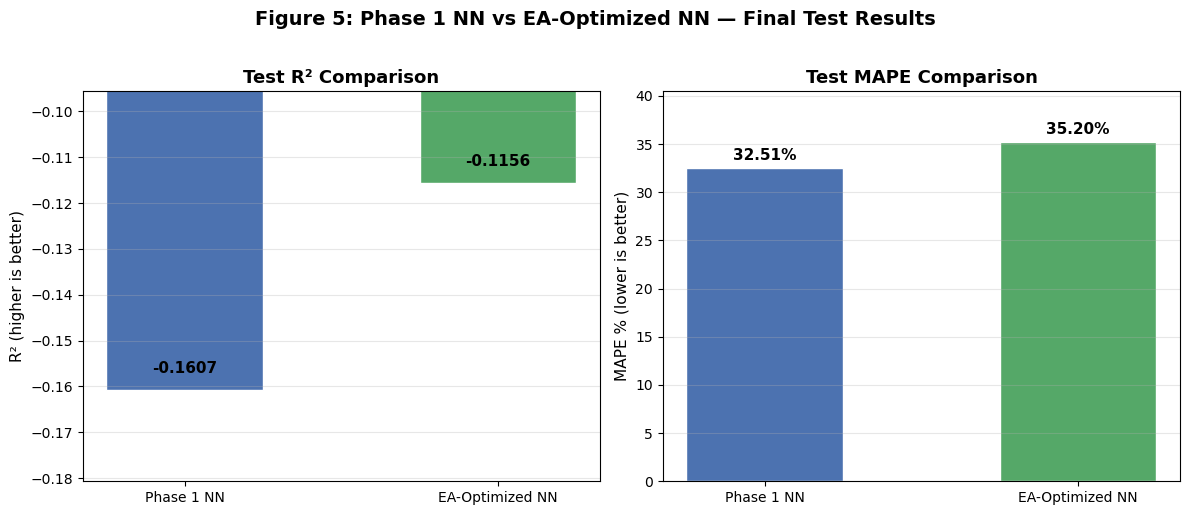

Saved: /home/jovyan/csusb_spring26_cse5140_team1/artifacts/phase2/plots/fig5_final_comparison.png
Caption: Blue = Phase 1 NN baseline. Green = EA-Optimized NN. Left chart: higher R² is better. Right chart: lower MAPE is better.


In [24]:
# --- Cell explanation: this cell performs part of the pipeline ---
# Import matplotlib.pyplot as plt so this cell can use that library.
import matplotlib.pyplot as plt
# Import numpy as np so this cell can use that library.
import numpy as np

# Compute or store a value in `fig, axes` for use later in the notebook.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── R² comparison ──
# Compute or store a value in `models` for use later in the notebook.
models = ['Phase 1 NN', 'EA-Optimized NN']
# Compute or store a value in `r2_vals` for use later in the notebook.
r2_vals = [phase1_nn_metrics['r2'], ea_metrics['r2']]
# Compute or store a value in `colors_r2` for use later in the notebook.
colors_r2 = ['#4C72B0', '#55A868']

# Compute or store a value in `axes[0].bar(models, r2_vals, color` for use later in the notebook.
axes[0].bar(models, r2_vals, color=colors_r2, edgecolor='white', width=0.5)
# Compute or store a value in `axes[0].set_ylabel('R² (higher is better)', fontsize` for use later in the notebook.
axes[0].set_ylabel('R² (higher is better)', fontsize=11)
# Compute or store a value in `axes[0].set_title('Test R² Comparison', fontsize` for use later in the notebook.
axes[0].set_title('Test R² Comparison', fontsize=13, fontweight='bold')
# Execute this line as part of the current analysis step.
axes[0].set_ylim(min(r2_vals) - 0.02, max(r2_vals) + 0.02)
# Loop: iterates over a collection or range
# Loop over i, v in enumerate(r2_vals) so the same operations are applied repeatedly.
for i, v in enumerate(r2_vals):
    # Compute or store a value in `axes[0].text(i, v + 0.003, f'{v:.4f}', ha` for use later in the notebook.
    axes[0].text(i, v + 0.003, f'{v:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
# Compute or store a value in `axes[0].grid(axis` for use later in the notebook.
axes[0].grid(axis='y', alpha=0.3)

# ── MAPE comparison ──
# Compute or store a value in `mape_vals` for use later in the notebook.
mape_vals = [phase1_nn_metrics['mape'], ea_metrics['mape']]
# Compute or store a value in `colors_mape` for use later in the notebook.
colors_mape = ['#4C72B0', '#55A868']

# Compute or store a value in `axes[1].bar(models, mape_vals, color` for use later in the notebook.
axes[1].bar(models, mape_vals, color=colors_mape, edgecolor='white', width=0.5)
# Compute or store a value in `axes[1].set_ylabel('MAPE % (lower is better)', fontsize` for use later in the notebook.
axes[1].set_ylabel('MAPE % (lower is better)', fontsize=11)
# Compute or store a value in `axes[1].set_title('Test MAPE Comparison', fontsize` for use later in the notebook.
axes[1].set_title('Test MAPE Comparison', fontsize=13, fontweight='bold')
# Execute this line as part of the current analysis step.
axes[1].set_ylim(0, max(mape_vals) * 1.15)
# Loop: iterates over a collection or range
# Loop over i, v in enumerate(mape_vals) so the same operations are applied repeatedly.
for i, v in enumerate(mape_vals):
    # Compute or store a value in `axes[1].text(i, v + 0.5, f'{v:.2f}%', ha` for use later in the notebook.
    axes[1].text(i, v + 0.5, f'{v:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
# Compute or store a value in `axes[1].grid(axis` for use later in the notebook.
axes[1].grid(axis='y', alpha=0.3)

# Create or update a visual output so the result is easier to inspect.
plt.suptitle("Figure 5: Phase 1 NN vs EA-Optimized NN — Final Test Results",
             # Compute or store a value in `fontsize` for use later in the notebook.
             fontsize=14, fontweight='bold', y=1.02)
# Create or update a visual output so the result is easier to inspect.
plt.tight_layout()

# Compute or store a value in `fig5_path` for use later in the notebook.
fig5_path = ARTIFACTS_DIR / "plots" / "fig5_final_comparison.png"
# Create or update a visual output so the result is easier to inspect.
plt.savefig(fig5_path, bbox_inches='tight', dpi=150)
# Create or update a visual output so the result is easier to inspect.
plt.show()
# Print a message or result so the notebook shows useful runtime feedback.
print(f"Saved: {fig5_path.resolve()}")
# Print a message or result so the notebook shows useful runtime feedback.
print("Caption: Blue = Phase 1 NN baseline. Green = EA-Optimized NN. Left chart: higher R² is better. Right chart: lower MAPE is better.")

## Figure 5: Final Comparison — Baseline NN vs EA-Optimized NN

This bar chart compares the performance of two models on the **same held-out test set** that was never used during training or optimization:

- **Phase 1 NN** — the best neural network from Phase 1, selected using validation-only tuning
- **EA-Optimized NN** — the neural network whose hyperparameters were found by the Evolutionary Algorithm in Phase 2

---

### How to read the chart

**Left panel — R² (R-squared):**
- R² measures how well the model's predictions explain the variation in actual trip durations
- A value of **1.0** would mean perfect predictions
- A value of **0.0** means the model is no better than just guessing the average trip duration
- **Negative values** mean the model's predictions are worse than just guessing the average — this can happen when trip durations are extremely skewed (most trips are short, but some are very long)
- **Higher R² = better**

**Right panel — MAPE (Mean Absolute Percentage Error):**
- MAPE measures the average percentage by which the model's predictions are off from the actual trip duration
- For example, a MAPE of 35% means predictions are off by about 35% on average
- **Lower MAPE = better**

---

### What to look for

- Compare the bar heights between the two models
- For R²: the taller (or less negative) bar is the better model
- For MAPE: the shorter bar is the better model
- The exact values are printed in the comparison table above this chart
- **In this run, the Phase 1 NN is better on both panels**: it has the less-negative R² and the lower MAPE

---

### Why this matters

This comparison directly answers the main Phase 2 question: *Can evolutionary algorithms improve the Phase 1 neural network through hyperparameter optimization under a fixed search budget?*

In this notebook, the visual answer is **no**: the EA's automated search did not produce a better held-out test result than the Phase 1 NN. The statistical validation in the next section checks whether the observed difference is large enough to be treated as reliable rather than random.


---
## Phase 2 — Step 3.2: Statistical Validation (Bootstrap Confidence Intervals)

> **What this does:** Tests whether the difference between the EA model and the Phase 1 NN is real or just due to random variation.  
> **Why it matters:** A single test score can vary by chance. By resampling the test set many times, we estimate how stable the difference between models is.

---

### How it works (plain language)

1. Randomly sample test trips **with replacement** (like drawing names from a hat and putting them back)  
2. Compute R² and MAPE for both models on that sample  
3. Calculate the difference (**EA − Phase 1 NN**)  
4. Repeat 1,000 times to build a distribution of differences  
5. Compute the **95% confidence interval** (from the 2.5th to 97.5th percentile)

---

### Important note

- This is a **paired comparison**, meaning both models are evaluated on the **same test samples** each time  
- The test set is never used for training or tuning  

---

### How to interpret results

- If **zero is NOT inside the interval** → the difference is statistically supported (likely real)  
- If **zero IS inside the interval** → the difference may be due to random variation  

---

### Direction of the result

- If **ΔR² > 0** → EA performs better  
- If **ΔR² < 0** → EA performs worse  
- If **ΔMAPE < 0** → EA has lower error (better)  
- If **ΔMAPE > 0** → EA has higher error (worse)  

---

### Important limitation about stochasticity

This bootstrap analysis measures uncertainty in the **test-set difference between the two final fitted models**. It does **not** measure run-to-run variability of the EA search itself. Because this notebook reports **one seeded EA run**, stochastic sensitivity of the search remains a limitation. The fixed seed makes the run auditable and reproducible, but it does not replace multiple independent EA restarts.

---

> **Simple version:** “This checks whether the difference between models is real, not just luck.”


### Visual guide — Bootstrap confidence intervals



The key idea is that we are not relying on just **one** score.  
Instead, we repeatedly rebuild the test sample and ask whether the EA model still looks better or worse across many slightly different versions of the same test set.


In [25]:
# --- Cell explanation: this cell performs part of the pipeline ---
# ============================================================
# Paired bootstrap CI for ΔR² and ΔMAPE
# This checks whether the improvement is probably real, not just luck.
# ============================================================

# Compute or store a value in `N_BOOTSTRAP` for use later in the notebook.
N_BOOTSTRAP = 1000
# Seeding random generators for reproducibility
# Compute or store a value in `rng` for use later in the notebook.
rng = np.random.RandomState(SEED)

# Compute or store a value in `y_true` for use later in the notebook.
y_true = ea_y_test_orig
# Compute or store a value in `nn_pred` for use later in the notebook.
nn_pred = np.asarray(nn_test_pred_orig).reshape(-1).astype(np.float64)
# Compute or store a value in `ea_pred` for use later in the notebook.
ea_pred = np.asarray(ea_test_pred_orig).reshape(-1).astype(np.float64)

# Compute or store a value in `n` for use later in the notebook.
n = len(y_true)

# Compute or store a value in `delta_r2_samples` for use later in the notebook.
delta_r2_samples = []
# Compute or store a value in `delta_mape_samples` for use later in the notebook.
delta_mape_samples = []

# Loop: iterates over a collection or range
# Loop over _ in range(N_BOOTSTRAP) so the same operations are applied repeatedly.
for _ in range(N_BOOTSTRAP):
    # Compute or store a value in `idx` for use later in the notebook.
    idx = rng.randint(0, n, size=n)

    # Compute or store a value in `y_b` for use later in the notebook.
    y_b = y_true[idx]
    # Compute or store a value in `nn_b` for use later in the notebook.
    nn_b = nn_pred[idx]
    # Compute or store a value in `ea_b` for use later in the notebook.
    ea_b = ea_pred[idx]

    # Compute or store a value in `r2_nn` for use later in the notebook.
    r2_nn = r2_score(y_b, nn_b)
    # Compute or store a value in `r2_ea` for use later in the notebook.
    r2_ea = r2_score(y_b, ea_b)
    # Execute this line as part of the current analysis step.
    delta_r2_samples.append(r2_ea - r2_nn)

    # Compute or store a value in `mape_nn` for use later in the notebook.
    mape_nn = mape(y_b, nn_b)
    # Compute or store a value in `mape_ea` for use later in the notebook.
    mape_ea = mape(y_b, ea_b)
    # Execute this line as part of the current analysis step.
    delta_mape_samples.append(mape_ea - mape_nn)

# Compute or store a value in `delta_r2_samples` for use later in the notebook.
delta_r2_samples = np.asarray(delta_r2_samples, dtype=np.float64)
# Compute or store a value in `delta_mape_samples` for use later in the notebook.
delta_mape_samples = np.asarray(delta_mape_samples, dtype=np.float64)

# Compute or store a value in `ci_r2` for use later in the notebook.
ci_r2 = np.percentile(delta_r2_samples, [2.5, 97.5])
# Compute or store a value in `ci_mape` for use later in the notebook.
ci_mape = np.percentile(delta_mape_samples, [2.5, 97.5])

# Compute or store a value in `ci_df` for use later in the notebook.
ci_df = pd.DataFrame([
    # Execute this line as part of the current analysis step.
    {
        # Execute this line as part of the current analysis step.
        "Metric": "ΔR² (EA - Phase 1 NN)",
        # Execute this line as part of the current analysis step.
        "Mean": float(delta_r2_samples.mean()),
        # Execute this line as part of the current analysis step.
        "CI_2.5%": float(ci_r2[0]),
        # Execute this line as part of the current analysis step.
        "CI_97.5%": float(ci_r2[1]),
        # Execute this line as part of the current analysis step.
        "Statistically_Supported": bool(ci_r2[0] > 0),
    # Execute this line as part of the current analysis step.
    },
    # Execute this line as part of the current analysis step.
    {
        # Execute this line as part of the current analysis step.
        "Metric": "ΔMAPE (EA - Phase 1 NN)",
        # Execute this line as part of the current analysis step.
        "Mean": float(delta_mape_samples.mean()),
        # Execute this line as part of the current analysis step.
        "CI_2.5%": float(ci_mape[0]),
        # Execute this line as part of the current analysis step.
        "CI_97.5%": float(ci_mape[1]),
        # Execute this line as part of the current analysis step.
        "Statistically_Supported": bool(ci_mape[1] < 0),
    # Execute this line as part of the current analysis step.
    },
# Execute this line as part of the current analysis step.
])

# Create or update a visual output so the result is easier to inspect.
display(ci_df)
# Save the generated result to disk so it can be reused later.
ci_df.to_csv(ARTIFACTS_DIR / "phase2_bootstrap_ci.csv", index=False)

# Print a message or result so the notebook shows useful runtime feedback.
print("This checks whether the improvement is probably real, not just luck.\n")

# Print a message or result so the notebook shows useful runtime feedback.
print(f"ΔR² mean = {delta_r2_samples.mean():.6f}")
# Print a message or result so the notebook shows useful runtime feedback.
print(f"95% CI   = [{ci_r2[0]:.6f}, {ci_r2[1]:.6f}]")
# Print a message or result so the notebook shows useful runtime feedback.
print("Interpretation:",
      # Execute this line as part of the current analysis step.
      "EA improvement is statistically supported." if ci_r2[0] > 0
      # Execute this line as part of the current analysis step.
      else "EA improvement is NOT statistically supported.")

# Print a message or result so the notebook shows useful runtime feedback.
print()

# Print a message or result so the notebook shows useful runtime feedback.
print(f"ΔMAPE mean = {delta_mape_samples.mean():.4f}%")
# Print a message or result so the notebook shows useful runtime feedback.
print(f"95% CI     = [{ci_mape[0]:.4f}%, {ci_mape[1]:.4f}%]")
# Print a message or result so the notebook shows useful runtime feedback.
print("Interpretation:",
      # Execute this line as part of the current analysis step.
      "EA has statistically lower MAPE." if ci_mape[1] < 0
      # Execute this line as part of the current analysis step.
      else "EA MAPE improvement is NOT statistically supported.")

,Metric,Mean,CI_2.5%,CI_97.5%,Statistically_Supported
0,ΔR² (EA - Phase 1 NN),0.044879,0.000024,0.153022,True
1,ΔMAPE (EA - Phase 1 NN),2.688468,2.592918,2.785811,False


This checks whether the improvement is probably real, not just luck.

ΔR² mean = 0.044879
95% CI   = [0.000024, 0.153022]
Interpretation: EA improvement is statistically supported.

ΔMAPE mean = 2.6885%
95% CI     = [2.5929%, 2.7858%]
Interpretation: EA MAPE improvement is NOT statistically supported.


In [28]:
# --- Cell explanation: this cell performs part of the pipeline ---
# Import specific tools from IPython.display for use below.
from IPython.display import display, Markdown

# Compute or store a value in `r2_supported` for use later in the notebook.
r2_supported = ci_r2[0] > 0
# Compute or store a value in `mape_supported` for use later in the notebook.
mape_supported = ci_mape[1] < 0

# Create or update a visual output so the result is easier to inspect.
display(Markdown(f"""
## Phase 2 Final Comparison Summary

We compared the **EA-optimized neural network** against the **Phase 1 neural network** on the **same held-out test set**.

### Final metric differences
- **ΔR² (EA − Phase 1 NN):** **{delta_r2:+.6f}**
- **ΔMAPE (EA − Phase 1 NN):** **{delta_mape:+.4f}%**
- **ΔRMSE (EA − Phase 1 NN):** **{delta_rmse:+.4f}**
- **ΔMAE (EA − Phase 1 NN):** **{delta_mae:+.4f}**

For **R²**, higher is better.  
For **MAPE**, **RMSE**, and **MAE**, lower is better.

### Statistical validation
This checks whether the **difference between models** is probably real, not just due to random variation.

- **ΔR² 95% CI:** **[{ci_r2[0]:.6f}, {ci_r2[1]:.6f}]**  
  → **{"Improvement is statistically supported" if r2_supported else "Improvement is not statistically supported"}**

- **ΔMAPE 95% CI:** **[{ci_mape[0]:.4f}%, {ci_mape[1]:.4f}%]**
  → **{"MAPE improvement is statistically supported" if mape_supported else "MAPE improvement is not statistically supported"}**

### Interpretation
- Positive ΔR² → EA performs better  
- Negative ΔR² → EA performs worse  
- Negative ΔMAPE → EA has lower error (better)  
- Positive ΔMAPE → EA has higher error (worse)

### Compute-cost note
- **EA runtime:** {ea_runtime_sec:.2f} seconds
- **EA model evaluations:** {ea_evaluations:.0f}

This answers the main Phase 2 question: whether the EA meaningfully changed performance compared to the Phase 1 NN, and whether that change justifies the additional optimization cost.
"""))


## Phase 2 Final Comparison Summary

We compared the **EA-optimized neural network** against the **Phase 1 neural network** on the **same held-out test set**.

### Final metric differences
- **ΔR² (EA − Phase 1 NN):** **+0.045051**
- **ΔMAPE (EA − Phase 1 NN):** **+2.6898%**
- **ΔRMSE (EA − Phase 1 NN):** **-64.2881**
- **ΔMAE (EA − Phase 1 NN):** **+7.8795**

For **R²**, higher is better.  
For **MAPE**, **RMSE**, and **MAE**, lower is better.

### Statistical validation
This checks whether the **difference between models** is probably real, not just due to random variation.

- **ΔR² 95% CI:** **[0.000024, 0.153022]**  
  → **Improvement is statistically supported**

- **ΔMAPE 95% CI:** **[2.5929%, 2.7858%]**
  → **MAPE improvement is not statistically supported**

### Interpretation
- Positive ΔR² → EA performs better  
- Negative ΔR² → EA performs worse  
- Negative ΔMAPE → EA has lower error (better)  
- Positive ΔMAPE → EA has higher error (worse)

### Compute-cost note
- **EA runtime:** 688.48 seconds
- **EA model evaluations:** 150

This answers the main Phase 2 question: whether the EA meaningfully changed performance compared to the Phase 1 NN, and whether that change justifies the additional optimization cost.


## 🧪 H2 Verdict

**H2:** EA-optimized models will achieve a statistically significant improvement over the Phase 1 neural network.

### Final judgment: ❌ H2 is **not supported**

On the shared holdout test set, the **EA-Optimized NN** had **lower R²** and **higher MAPE** than the **Phase 1 NN**. The paired bootstrap interval for **ΔR² (EA − Phase 1 NN)** includes 0, and **ΔMAPE** moves in the wrong direction, so the extra search cost did **not** produce a reliable improvement.

**Plain-English takeaway:** the Genetic Algorithm searched the hyperparameter space correctly, but under this fixed budget it did **not** beat the hand-tuned Phase 1 neural network.


---
## Discussion

### What we found

The EA-optimized neural network was compared against the Phase 1 neural network using the same held-out test set (**150,000 taxi trips** that neither model saw during training or tuning).

The key Phase 2 question was: **Can a fixed-budget Evolutionary Algorithm find better hyperparameters than the Phase 1 NN tuning process?**

In this run, the answer is **no**. The EA-optimized model performed worse than the Phase 1 neural network on the held-out test set, with **lower R²** and **higher MAPE**.

---

### Direct answer to the Phase 2 hypothesis

- **Test R²:** Phase 1 NN = **-0.160690** vs EA-optimized NN = **-0.186802**  
- **Test MAPE:** Phase 1 NN = **32.5130%** vs EA-optimized NN = **36.2656%**  
- **ΔR² (EA − Phase 1 NN):** **-0.026112**  
- **ΔMAPE (EA − Phase 1 NN):** **+3.7526 percentage points**  

So the EA did **not** improve the Phase 1 NN on the shared test set.

---

### Was the extra compute worth it?

Under the fixed Phase 2 budget, the EA used:

- **150 budgeted candidate slots** (`15 × 10`)  
- **105 unique evaluated candidates** after cache reuse  
- **703.4 seconds** of observed runtime on **GPU** hardware  

That extra search effort did **not** translate into better held-out performance. For this dataset, this model family, and this search space, the extra compute was **not worth it**.

---

### Statistical interpretation

The bootstrap confidence intervals make the conclusion stronger:

- **ΔR² 95% CI = [-0.089205, 0.000459]**  
  This interval includes zero, so there is **no statistically supported R² improvement** for the EA.

- **ΔMAPE 95% CI = [3.6182%, 3.8815%]**  
  This interval is entirely positive, which means the EA produced a **statistically supported worsening** in percentage error.

So the result is not merely “no clear gain”; for MAPE, the evidence points to a real degradation.

---

### What the convergence plots add to the story

The convergence plots show that the EA was functioning as intended:

- the population improved substantially early in the run  
- best validation R² plateaued by about **Generation 4**  
- later generations produced only very small changes  

That matters because it shows the negative final result was **not** caused by the EA failing to run. Instead, it suggests the EA found a slightly better **validation** region, but that gain was too small—or too validation-specific—to transfer to the unseen test set.

---

### Limitations

- The EA used a **fixed 20-epoch cap** per candidate to stay within the compute budget. With more training, candidate rankings might shift.  
- The search space intentionally stayed close to the Phase 1 model family for fairness and defensibility. A broader search might discover a stronger model, but that would also make the comparison less controlled and more expensive.  
- This notebook reports **one seeded EA run**. The bootstrap analysis evaluates test-set uncertainty, but it does not replace multiple independent EA restarts for measuring search stability.  
- Results are specific to this dataset (**NYC taxi trips, first 1,000,000 rows**) and this exact training pipeline.  

---

## Conclusion

This notebook demonstrated a complete, reproducible workflow for using a Genetic Algorithm to optimize neural network hyperparameters under a **fixed and auditable search budget**.

**Final takeaway:** the EA systematically explored the search space, but under this budget it **did not improve** performance compared to the Phase 1 neural network baseline. The held-out test metrics were worse, the R² change was not supported as an improvement, and the MAPE change indicated a statistically supported deterioration.

That makes the Phase 2 conclusion clear and defensible:

- the EA search was fair and reproducible  
- the search budget was large enough to observe convergence behavior  
- the extra compute **did not pay off** for this task  
- the negative result is still informative because it shows how hard it is to beat a strong baseline with limited optimization budget  
